
(process:588): Pango-WARNING **: 10:07:36.397: couldn't load font "Times New Not-Rotated 26", falling back to "Sans Not-Rotated 26", expect ugly output.

(process:588): Pango-WARNING **: 10:07:36.494: couldn't load font "Times New Not-Rotated 30", falling back to "Sans Not-Rotated 30", expect ugly output.

(process:588): Pango-WARNING **: 10:07:36.501: couldn't load font "Times New Not-Rotated 34", falling back to "Sans Not-Rotated 34", expect ugly output.

(process:10844): Pango-WARNING **: 10:07:37.253: couldn't load font "Times New Not-Rotated 26", falling back to "Sans Not-Rotated 26", expect ugly output.

(process:10844): Pango-WARNING **: 10:07:37.283: couldn't load font "Times New Not-Rotated 30", falling back to "Sans Not-Rotated 30", expect ugly output.

(process:10844): Pango-WARNING **: 10:07:37.288: couldn't load font "Times New Not-Rotated 34", falling back to "Sans Not-Rotated 34", expect ugly output.


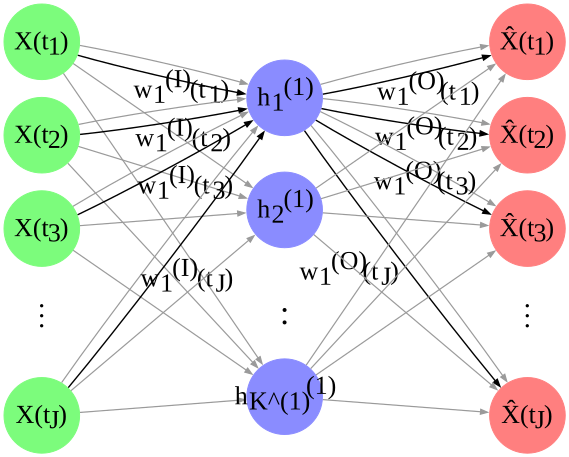

In [4]:
from graphviz import Digraph

dot = Digraph("FAE", engine="neato")  # <-- use neato for fixed positions

# --- global graph style ---
dot.attr(
    overlap="false",
    splines="false",     # straight edges
    bgcolor="white",
    outputorder="edgesfirst"
)

dot.attr(
    "node",
    shape="circle",
    fixedsize="true",
    width="1.05",
    fontsize="26",
    fontname="Times New Roman"
)

dot.attr(
    "edge",
    arrowsize="0.7",
    penwidth="1.3",
    color="#9a9a9a"
)

# Helper: HTML label wrapper
def H(s):
    return f"<{s}>"

# -------------------------
# Fixed coordinates (x,y)
# -------------------------
xL, xM, xR = 0.0, 2.6, 5.2

# Left inputs (top to bottom)
pos = {
    "X1": (xL, 4.0),
    "X2": (xL, 3.0),
    "X3": (xL, 2.0),
    "Xd": (xL, 1.0),
    "XJ": (xL, 0.0),

    # Hidden (middle)
    "H1": (xM, 3.4),
    "H2": (xM, 2.2),
    "Hd": (xM, 1.1),
    "HK": (xM, 0.2),

    # Right outputs (top to bottom)
    "Y1": (xR, 4.0),
    "Y2": (xR, 3.0),
    "Y3": (xR, 2.0),
    "Yd": (xR, 1.0),
    "YJ": (xR, 0.0),
}

def set_pos(name):
    x, y = pos[name]
    return f"{x},{y}!"

# ---- Input nodes (green) ----
dot.node("X1", H("X(t<sub>1</sub>)"), pos=set_pos("X1"),
         style="filled", fillcolor="#7CFC7C", color="#7CFC7C")
dot.node("X2", H("X(t<sub>2</sub>)"), pos=set_pos("X2"),
         style="filled", fillcolor="#7CFC7C", color="#7CFC7C")
dot.node("X3", H("X(t<sub>3</sub>)"), pos=set_pos("X3"),
         style="filled", fillcolor="#7CFC7C", color="#7CFC7C")
dot.node("Xd", "⋮", pos=set_pos("Xd"), shape="plaintext", fontsize="30")
dot.node("XJ", H("X(t<sub>J</sub>)"), pos=set_pos("XJ"),
         style="filled", fillcolor="#7CFC7C", color="#7CFC7C")

# ---- Hidden nodes (blue) ----
dot.node("H1", H("h<sub>1</sub><sup>(1)</sup>"), pos=set_pos("H1"),
         style="filled", fillcolor="#8A8CFF", color="#8A8CFF")
dot.node("H2", H("h<sub>2</sub><sup>(1)</sup>"), pos=set_pos("H2"),
         style="filled", fillcolor="#8A8CFF", color="#8A8CFF")
dot.node("Hd", ":", pos=set_pos("Hd"), shape="plaintext", fontsize="34")
dot.node("HK", H("h<sub>K^(1)</sub><sup>(1)</sup>"), pos=set_pos("HK"),
         style="filled", fillcolor="#8A8CFF", color="#8A8CFF")

# ---- Output nodes (red) ----
# Use combining-hat: X̂  (works nicely in HTML labels)
dot.node("Y1", H("X&#770;(t<sub>1</sub>)"), pos=set_pos("Y1"),
         style="filled", fillcolor="#FF7F7F", color="#FF7F7F")
dot.node("Y2", H("X&#770;(t<sub>2</sub>)"), pos=set_pos("Y2"),
         style="filled", fillcolor="#FF7F7F", color="#FF7F7F")
dot.node("Y3", H("X&#770;(t<sub>3</sub>)"), pos=set_pos("Y3"),
         style="filled", fillcolor="#FF7F7F", color="#FF7F7F")
dot.node("Yd", "⋮", pos=set_pos("Yd"), shape="plaintext", fontsize="30")
dot.node("YJ", H("X&#770;(t<sub>J</sub>)"), pos=set_pos("YJ"),
         style="filled", fillcolor="#FF7F7F", color="#FF7F7F")

# ---------------------------------
# Dense connections (light gray)
# ---------------------------------
inputs  = ["X1", "X2", "X3", "XJ"]
hidden  = ["H1", "H2", "HK"]
outputs = ["Y1", "Y2", "Y3", "YJ"]

dot.attr("edge", color="#9a9a9a", penwidth="1.2")
for x in inputs:
    for h in hidden:
        dot.edge(x, h)

for h in hidden:
    for y in outputs:
        dot.edge(h, y)

# ---------------------------------
# Highlight edges (black) + labels
# ---------------------------------
dot.attr("edge", color="black", penwidth="1.4", fontsize="26", fontname="Times New Roman")

# Input weight labels
dot.edge("X1", "H1", label=H("w<sub>1</sub><sup>(I)</sup>(t<sub>1</sub>)"))
dot.edge("X2", "H1", label=H("w<sub>1</sub><sup>(I)</sup>(t<sub>2</sub>)"))
dot.edge("X3", "H1", label=H("w<sub>1</sub><sup>(I)</sup>(t<sub>3</sub>)"))
dot.edge("XJ", "H1", label=H("w<sub>1</sub><sup>(I)</sup>(t<sub>J</sub>)"))

# Output weight labels
dot.edge("H1", "Y1", label=H("w<sub>1</sub><sup>(O)</sup>(t<sub>1</sub>)"))
dot.edge("H1", "Y2", label=H("w<sub>1</sub><sup>(O)</sup>(t<sub>2</sub>)"))
dot.edge("H1", "Y3", label=H("w<sub>1</sub><sup>(O)</sup>(t<sub>3</sub>)"))
dot.edge("H1", "YJ", label=H("w<sub>1</sub><sup>(O)</sup>(t<sub>J</sub>)"))

# --- render ---
dot.format = "png"
dot.render("FAE", cleanup=True)

dot


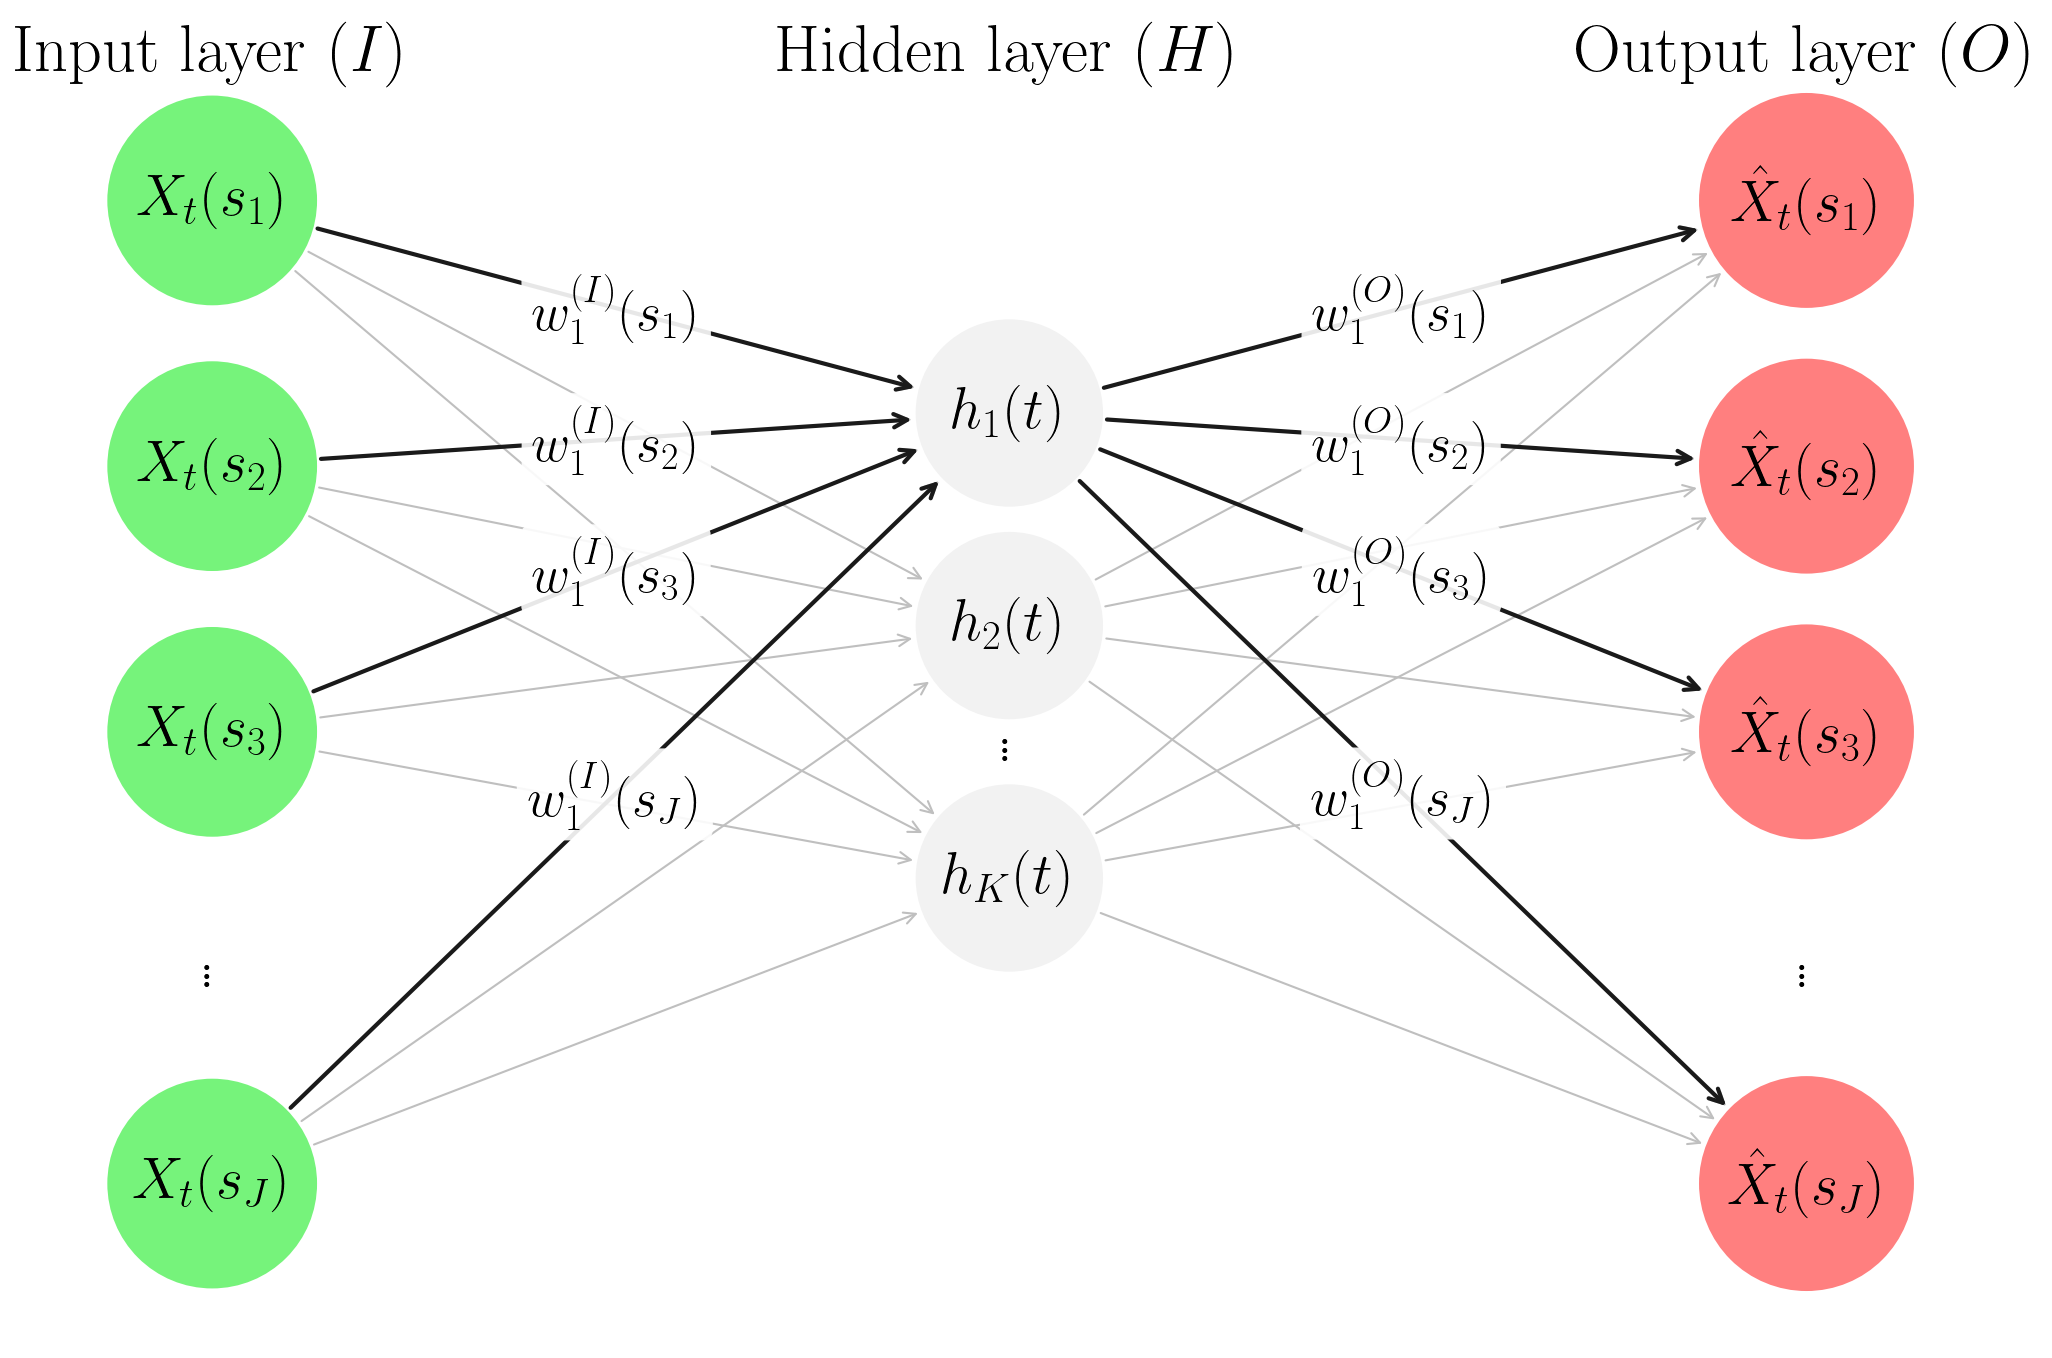

In [5]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# ---------- LaTeX rendering ----------
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 22,  # bigger text overall
    "text.latex.preamble": r"\usepackage{amsmath}"
})

# ---------- Geometry helpers ----------
def unit(v):
    v = np.array(v, dtype=float)
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

def arrow_endpoints(p1, r1, p2, r2):
    """Return endpoints on the boundaries of circles centered at p1/p2 with radii r1/r2."""
    p1 = np.array(p1, float)
    p2 = np.array(p2, float)
    d = p2 - p1
    u = unit(d)
    a = p1 + u * r1
    b = p2 - u * r2
    return a, b

# ---------- Drawing helpers ----------
def add_node(ax, xy, facecolor, text, fontsize=22):
    """
    Create text first (for measuring), then later we will draw the circle with correct radius.
    Returns a dict holding position, text object, computed radius.
    """
    txt = ax.text(xy[0], xy[1], text, ha="center", va="center",
                  fontsize=fontsize, zorder=10)
    return {"xy": xy, "facecolor": facecolor, "text": text, "txtobj": txt, "r": None}

def compute_radii(ax, groups, pad_px=10):
    """
    groups = list of lists of nodes (e.g., [XL, XM, XR])
    All nodes inside one group get the same radius.
    """
    renderer = ax.figure.canvas.get_renderer()

    # data-units per pixel
    x0 = ax.transData.transform((0, 0))[0]
    x1 = ax.transData.transform((1, 0))[0]
    data_per_px = 1.0 / abs(x1 - x0)

    for group in groups:
        max_r_px = 0

        # find largest text box in this column
        for nd in group:
            bbox = nd["txtobj"].get_window_extent(renderer=renderer)
            w_px = bbox.width + 2 * pad_px
            h_px = bbox.height + 2 * pad_px
            r_px = 0.5 * np.sqrt(w_px**2 + h_px**2)
            max_r_px = max(max_r_px, r_px)

        # assign same radius to all nodes in column
        for nd in group:
            nd["r"] = max_r_px * data_per_px

def draw_circles(ax, nodes, edge_lw=0.0):
    """Draw circles after radii have been computed."""
    for nd in nodes:
        circ = Circle(nd["xy"], nd["r"], facecolor=nd["facecolor"],
                      edgecolor=nd["facecolor"], lw=edge_lw, zorder=5)
        ax.add_patch(circ)

def add_arrow(ax, p1, r1, p2, r2, color="0.75", lw=1.2, ms=14, z=2):
    """Arrow that starts/ends at circle boundaries."""
    a, b = arrow_endpoints(p1, r1, p2, r2)
    arr = FancyArrowPatch(
        a, b, arrowstyle="->",
        mutation_scale=ms,
        lw=lw, color=color,
        zorder=z
    )
    ax.add_patch(arr)

def add_edge_label(ax, p1, r1, p2, r2, label, t=0.5, offset=0.0, fontsize=26, z=20):
    # endpoints of the visible arrow (touching circle boundaries)
    a, b = arrow_endpoints(p1, r1, p2, r2)

    # point on the arrow
    x = (1 - t) * a[0] + t * b[0]
    y = (1 - t) * a[1] + t * b[1]

    # optional small perpendicular offset (keeps it off the line if you want)
    d = np.array(b) - np.array(a)
    n = unit([-d[1], d[0]])
    x += offset * n[0]
    y += offset * n[1]

    ax.text(x, y, label, ha="center", va="center", fontsize=fontsize, zorder=z,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.9))


# ---------- Figure (BIGGER) ----------
fig, ax = plt.subplots(figsize=(16,12), dpi=150)
ax.axis("off")
ax.set_facecolor("white")
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")

# ---------- Layout ----------
xL, xM, xR = -0.10, 0.50, 1.10
y1, y2, y3, yJ = 0.86, 0.66, 0.46, 0.12

green, blue, red = "#76F37B", "#f2f2f2ff", "#FF7F7F"

XL_pos = [(xL, y1), (xL, y2), (xL, y3), (xL, yJ)]
XM_pos = [(xM, 0.70), (xM, 0.54), (xM, 0.35)]
XR_pos = [(xR, y1), (xR, y2), (xR, y3), (xR, yJ)]

# ---------- Create nodes (text first) ----------
nodes = []

# Inputs (changed LaTeX only)
XL = []
for p, t in zip(XL_pos, [r"$X_t(s_1)$", r"$X_t(s_2)$", r"$X_t(s_3)$", r"$X_t(s_J)$"]):
    nd = add_node(ax, p, green, t, fontsize=28)
    nodes.append(nd)
    XL.append(nd)

# Hidden (changed LaTeX only)
XM = []
for p, t in zip(XM_pos, [r"$h_1(t)$", r"$h_2(t)$", r"$h_K(t)$"]):
    nd = add_node(ax, p, blue, t, fontsize=28)
    nodes.append(nd)
    XM.append(nd)

# Outputs (changed LaTeX only)
XR = []
for p, t in zip(XR_pos, [r"$\hat X_t(s_1)$", r"$\hat X_t(s_2)$", r"$\hat X_t(s_3)$", r"$\hat X_t(s_J)$"]):
    nd = add_node(ax, p, red, t, fontsize=28)
    nodes.append(nd)
    XR.append(nd)

# Dots (not circles)
ax.text(xL, 0.28, r"$\vdots$", fontsize=30, ha="center", va="center", zorder=30)
ax.text(xM, 0.45, r"$\vdots$", fontsize=30,
        ha="center", va="center", zorder=30)

ax.text(xR, 0.28, r"$\vdots$", fontsize=30, ha="center", va="center", zorder=30)

# ---------- Measure text -> compute radii -> draw circles ----------
fig.canvas.draw()                 # IMPORTANT: needed before measuring bbox
compute_radii(ax, [XL, XM, XR], pad_px=16)  # more padding so circles cover text nicely
draw_circles(ax, nodes, edge_lw=0.0)

# ---------- Edges ----------
# Gray dense connections
for x in XL:
    for h in XM:
        add_arrow(ax, x["xy"], x["r"], h["xy"], h["r"], color="0.75", lw=1.0, ms=14, z=1)

for h in XM:
    for y in XR:
        add_arrow(ax, h["xy"], h["r"], y["xy"], y["r"], color="0.75", lw=1.0, ms=14, z=1)

# Highlighted edges (black)
for x in XL:
    add_arrow(ax, x["xy"], x["r"], XM[0]["xy"], XM[0]["r"], color="0.10", lw=2.0, ms=16, z=5)

for y in XR:
    add_arrow(ax, XM[0]["xy"], XM[0]["r"], y["xy"], y["r"], color="0.10", lw=2.0, ms=16, z=5)

# ---------- Weight labels (changed LaTeX only) ----------
# Input → hidden
add_edge_label(ax, XL[0]["xy"], XL[0]["r"], XM[0]["xy"], XM[0]["r"], r"$w^{(I)}_1(s_1)$")
add_edge_label(ax, XL[1]["xy"], XL[1]["r"], XM[0]["xy"], XM[0]["r"], r"$w^{(I)}_1(s_2)$")
add_edge_label(ax, XL[2]["xy"], XL[2]["r"], XM[0]["xy"], XM[0]["r"], r"$w^{(I)}_1(s_3)$")
add_edge_label(ax, XL[3]["xy"], XL[3]["r"], XM[0]["xy"], XM[0]["r"], r"$w^{(I)}_1(s_J)$")

# Hidden → output
add_edge_label(ax, XM[0]["xy"], XM[0]["r"], XR[0]["xy"], XR[0]["r"], r"$w^{(O)}_1(s_1)$")
add_edge_label(ax, XM[0]["xy"], XM[0]["r"], XR[1]["xy"], XR[1]["r"], r"$w^{(O)}_1(s_2)$")
add_edge_label(ax, XM[0]["xy"], XM[0]["r"], XR[2]["xy"], XR[2]["r"], r"$w^{(O)}_1(s_3)$")
add_edge_label(ax, XM[0]["xy"], XM[0]["r"], XR[3]["xy"], XR[3]["r"], r"$w^{(O)}_1(s_J)$")


# ---------- Column titles (NEW) ----------
y_title = 0.97
ax.text(xL, y_title, r"Input layer $(I)$",  ha="center", va="center", fontsize=32, zorder=50)
ax.text(xM, y_title, r"Hidden layer $(H)$", ha="center", va="center", fontsize=32, zorder=50)
ax.text(xR, y_title, r"Output layer $(O)$", ha="center", va="center", fontsize=32, zorder=50)


# ---------- Export (big, clean) ----------
plt.savefig("fae_latex_big.pdf", bbox_inches="tight")  # vector PDF
plt.savefig("fae_latex_big.svg", bbox_inches="tight")  # vector SVG
#plt.savefig("fae_latex_big.png", bbox_inches="tight", dpi=200)  # high-res PNG
plt.show()

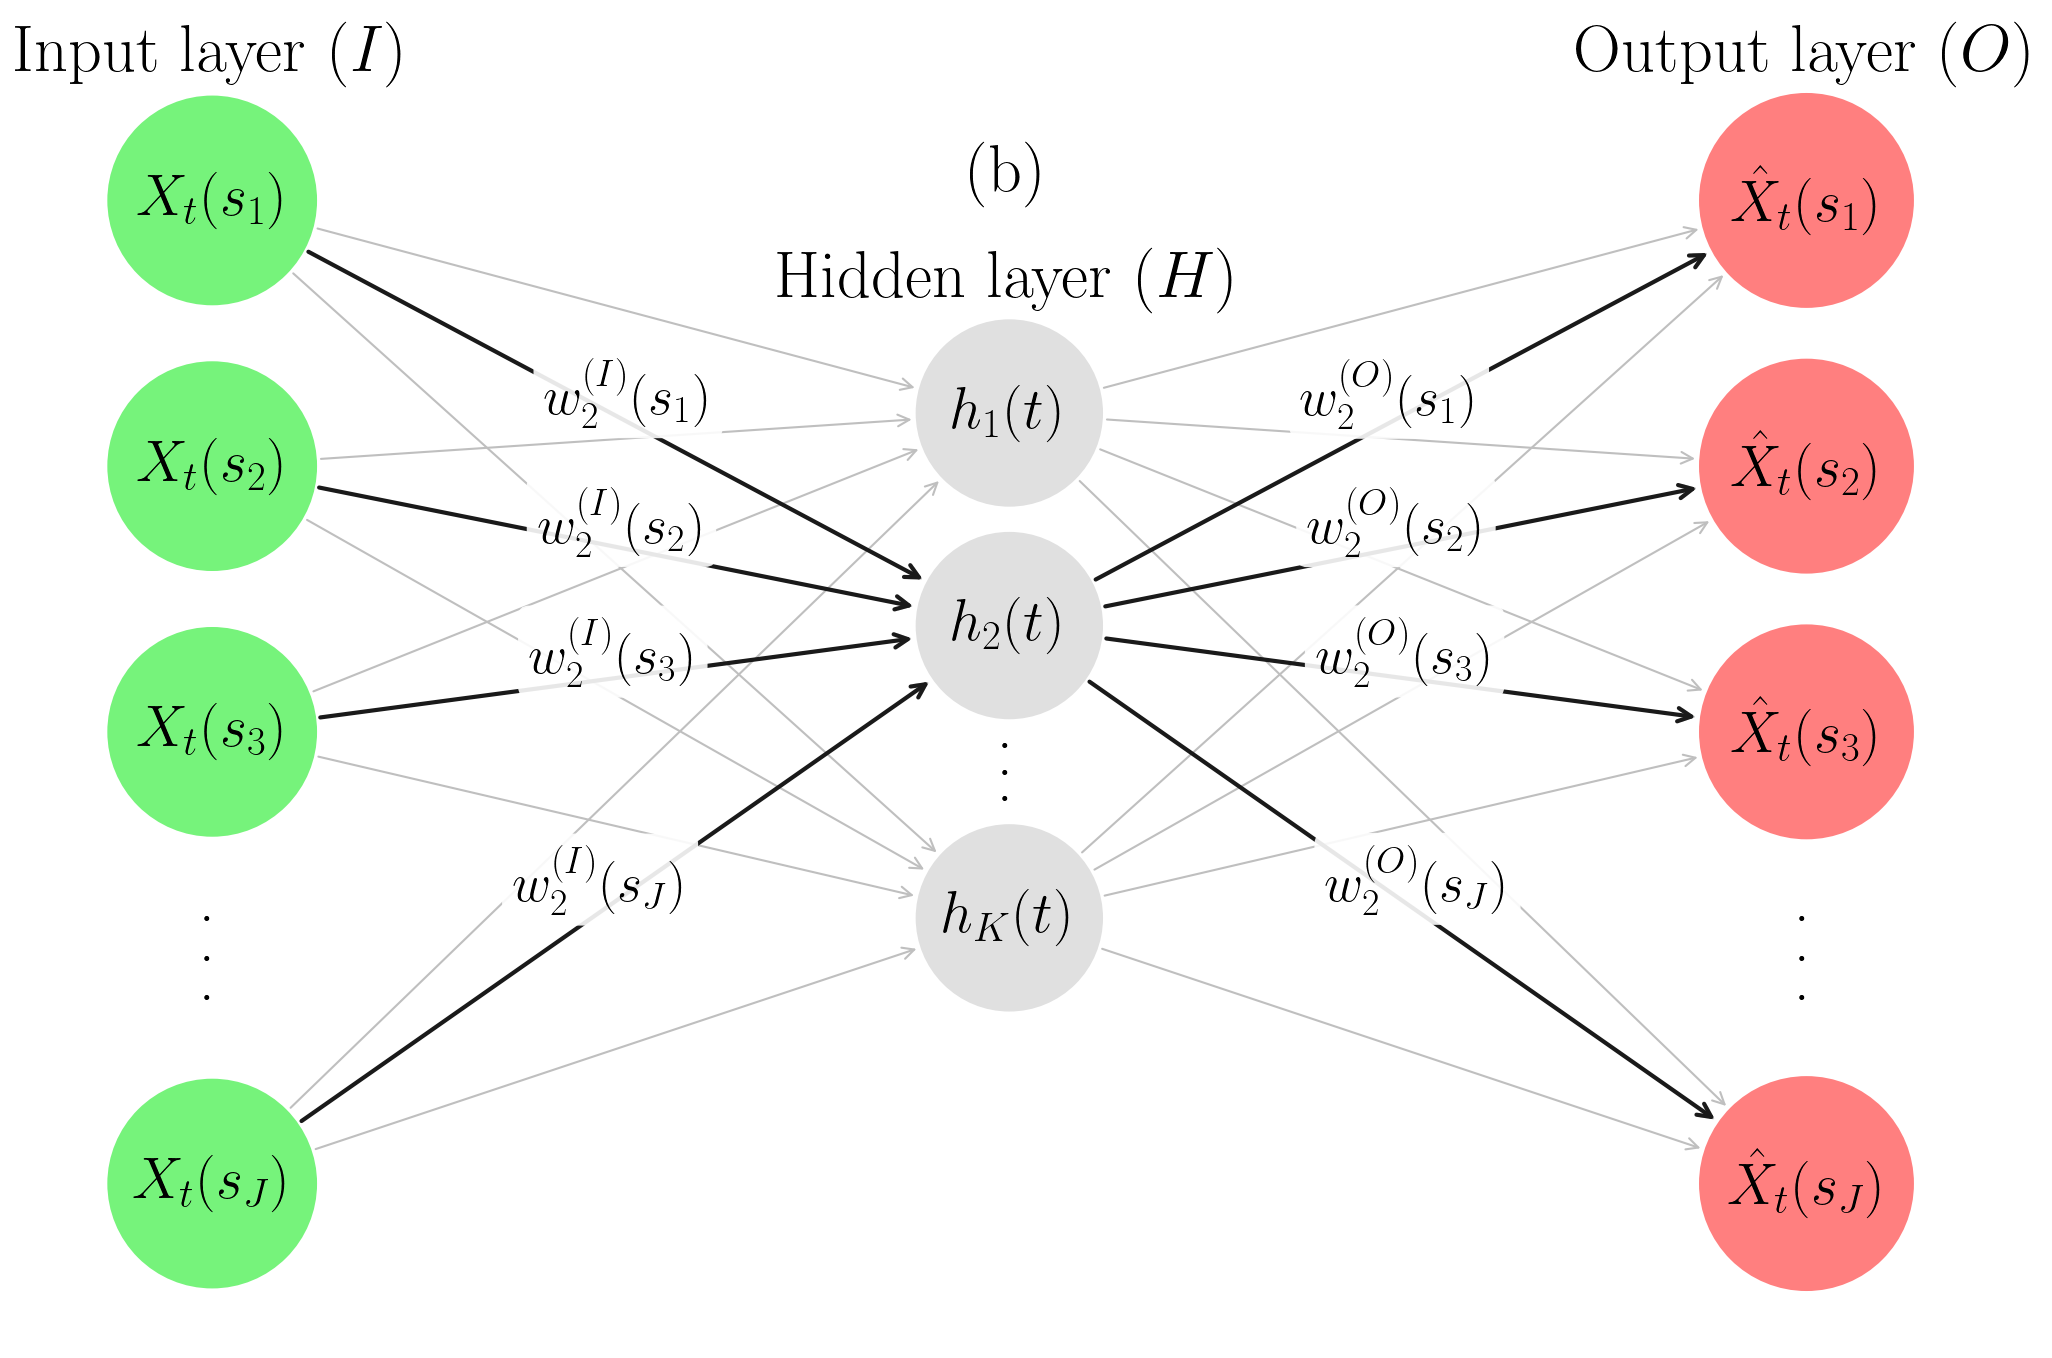

In [6]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# ---------- LaTeX rendering ----------
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 22,  # bigger text overall
    "text.latex.preamble": r"\usepackage{amsmath}"
})

# ---------- Geometry helpers ----------
def unit(v):
    v = np.array(v, dtype=float)
    n = np.linalg.norm(v)
    return v / n if n > 0 else v


def vertical_dots(x, y_center, gap=0.04, size=30):
    ax.text(x, y_center + gap, ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center,       ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center - gap, ".", fontsize=size, ha="center", va="center")


def arrow_endpoints(p1, r1, p2, r2):
    """Return endpoints on the boundaries of circles centered at p1/p2 with radii r1/r2."""
    p1 = np.array(p1, float)
    p2 = np.array(p2, float)
    d = p2 - p1
    u = unit(d)
    a = p1 + u * r1
    b = p2 - u * r2
    return a, b

# ---------- Drawing helpers ----------
def add_node(ax, xy, facecolor, text, fontsize=22):
    """
    Create text first (for measuring), then later we will draw the circle with correct radius.
    Returns a dict holding position, text object, computed radius.
    """
    txt = ax.text(xy[0], xy[1], text, ha="center", va="center",
                  fontsize=fontsize, zorder=10)
    return {"xy": xy, "facecolor": facecolor, "text": text, "txtobj": txt, "r": None}

def compute_radii(ax, groups, pad_px=10):
    """
    groups = list of lists of nodes (e.g., [XL, XM, XR])
    All nodes inside one group get the same radius.
    """
    renderer = ax.figure.canvas.get_renderer()

    # data-units per pixel
    x0 = ax.transData.transform((0, 0))[0]
    x1 = ax.transData.transform((1, 0))[0]
    data_per_px = 1.0 / abs(x1 - x0)

    for group in groups:
        max_r_px = 0

        # find largest text box in this column
        for nd in group:
            bbox = nd["txtobj"].get_window_extent(renderer=renderer)
            w_px = bbox.width + 2 * pad_px
            h_px = bbox.height + 2 * pad_px
            r_px = 0.5 * np.sqrt(w_px**2 + h_px**2)
            max_r_px = max(max_r_px, r_px)

        # assign same radius to all nodes in column
        for nd in group:
            nd["r"] = max_r_px * data_per_px

def draw_circles(ax, nodes, edge_lw=0.0):
    """Draw circles after radii have been computed."""
    for nd in nodes:
        circ = Circle(nd["xy"], nd["r"], facecolor=nd["facecolor"],
                      edgecolor=nd["facecolor"], lw=edge_lw, zorder=5)
        ax.add_patch(circ)

def add_arrow(ax, p1, r1, p2, r2, color="0.75", lw=1.2, ms=14, z=2):
    """Arrow that starts/ends at circle boundaries."""
    a, b = arrow_endpoints(p1, r1, p2, r2)
    arr = FancyArrowPatch(
        a, b, arrowstyle="->",
        mutation_scale=ms,
        lw=lw, color=color,
        zorder=z
    )
    ax.add_patch(arr)

def add_edge_label(ax, p1, r1, p2, r2, label, t=0.5, offset=0.0, fontsize=26, z=20):
    # endpoints of the visible arrow (touching circle boundaries)
    a, b = arrow_endpoints(p1, r1, p2, r2)

    # point on the arrow
    x = (1 - t) * a[0] + t * b[0]
    y = (1 - t) * a[1] + t * b[1]

    # optional small perpendicular offset (keeps it off the line if you want)
    d = np.array(b) - np.array(a)
    n = unit([-d[1], d[0]])
    x += offset * n[0]
    y += offset * n[1]

    ax.text(x, y, label, ha="center", va="center", fontsize=fontsize, zorder=z,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.9))


# ---------- Figure (BIGGER) ----------
fig, ax = plt.subplots(figsize=(16,12), dpi=150)
ax.axis("off")
ax.set_facecolor("white")
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")

# ---------- Layout ----------
xL, xM, xR = -0.10, 0.50, 1.10
y1, y2, y3, yJ = 0.86, 0.66, 0.46, 0.12

green, blue, red = "#76F37B", "#E0E0E0", "#FF7F7F"

XL_pos = [(xL, y1), (xL, y2), (xL, y3), (xL, yJ)]
XM_pos = [(xM, 0.70), (xM, 0.54), (xM, 0.32)]
XR_pos = [(xR, y1), (xR, y2), (xR, y3), (xR, yJ)]

# ---------- Create nodes (text first) ----------
nodes = []

# Inputs (changed LaTeX only)
XL = []
for p, t in zip(XL_pos, [r"$X_t(s_1)$", r"$X_t(s_2)$", r"$X_t(s_3)$", r"$X_t(s_J)$"]):
    nd = add_node(ax, p, green, t, fontsize=28)
    nodes.append(nd)
    XL.append(nd)

# Hidden (changed LaTeX only)
XM = []
for p, t in zip(XM_pos, [r"$h_1(t)$", r"$h_2(t)$", r"$h_K(t)$"]):
    nd = add_node(ax, p, blue, t, fontsize=28)
    nodes.append(nd)
    XM.append(nd)

# Outputs (changed LaTeX only)
XR = []
for p, t in zip(XR_pos, [r"$\hat X_t(s_1)$", r"$\hat X_t(s_2)$", r"$\hat X_t(s_3)$", r"$\hat X_t(s_J)$"]):
    nd = add_node(ax, p, red, t, fontsize=28)
    nodes.append(nd)
    XR.append(nd)

# Dots (not circles)
vertical_dots(xL, 0.30, gap=0.03)
vertical_dots(xM, 0.44, gap=0.02)
vertical_dots(xR, 0.30, gap=0.03)
#ax.text(xL, 0.28, r"$\vdots$", fontsize=30, ha="center", va="center", zorder=30)
#ax.text(xM, 0.45, r"$\vdots$", fontsize=30, ha="center", va="center", zorder=30)
#ax.text(xR, 0.28, r"$\vdots$", fontsize=30, ha="center", va="center", zorder=30)

# ---------- Measure text -> compute radii -> draw circles ----------
fig.canvas.draw()                 # IMPORTANT: needed before measuring bbox
compute_radii(ax, [XL, XM, XR], pad_px=16)  # more padding so circles cover text nicely
draw_circles(ax, nodes, edge_lw=0.0)

# ---------- Edges ----------
# Gray dense connections
for x in XL:
    for h in XM:
        add_arrow(ax, x["xy"], x["r"], h["xy"], h["r"], color="0.75", lw=1.0, ms=14, z=1)

for h in XM:
    for y in XR:
        add_arrow(ax, h["xy"], h["r"], y["xy"], y["r"], color="0.75", lw=1.0, ms=14, z=1)

# Highlighted edges (black) -> second hidden node h_2(t)
for x in XL:
    add_arrow(ax, x["xy"], x["r"], XM[1]["xy"], XM[1]["r"], color="0.10", lw=2.0, ms=16, z=5)

for y in XR:
    add_arrow(ax, XM[1]["xy"], XM[1]["r"], y["xy"], y["r"], color="0.10", lw=2.0, ms=16, z=5)

# ---------- Weight labels (changed LaTeX only) ----------
# Input → hidden (black labels centered on arrow)
add_edge_label(ax, XL[0]["xy"], XL[0]["r"], XM[1]["xy"], XM[1]["r"], r"$w^{(I)}_2(s_1)$", t=0.5, offset=0.02)
add_edge_label(ax, XL[1]["xy"], XL[1]["r"], XM[1]["xy"], XM[1]["r"], r"$w^{(I)}_2(s_2)$", t=0.5, offset=0.02)
add_edge_label(ax, XL[2]["xy"], XL[2]["r"], XM[1]["xy"], XM[1]["r"], r"$w^{(I)}_2(s_3)$", t=0.5, offset=0.02)
add_edge_label(ax, XL[3]["xy"], XL[3]["r"], XM[1]["xy"], XM[1]["r"], r"$w^{(I)}_2(s_J)$", t=0.5, offset=0.02)

# Hidden → output (black labels centered on arrow)
add_edge_label(ax, XM[1]["xy"], XM[1]["r"], XR[0]["xy"], XR[0]["r"], r"$w^{(O)}_2(s_1)$", t=0.5, offset=0.02)
add_edge_label(ax, XM[1]["xy"], XM[1]["r"], XR[1]["xy"], XR[1]["r"], r"$w^{(O)}_2(s_2)$", t=0.5, offset=0.02)
add_edge_label(ax, XM[1]["xy"], XM[1]["r"], XR[2]["xy"], XR[2]["r"], r"$w^{(O)}_2(s_3)$", t=0.5, offset=0.02)
add_edge_label(ax, XM[1]["xy"], XM[1]["r"], XR[3]["xy"], XR[3]["r"], r"$w^{(O)}_2(s_J)$", t=0.5, offset=0.02)


# ---------- Column titles (NEW) ----------
y_title = 0.97
ax.text(xL, y_title, r"Input layer $(I)$",  ha="center", va="center", fontsize=32, zorder=50)
ax.text(xM, 0.88, r"(b)", ha="center", va="center", fontsize=32, zorder=50)
ax.text(xM, 0.8, r"Hidden layer $(H)$", ha="center", va="center", fontsize=32, zorder=50)
ax.text(xR, y_title, r"Output layer $(O)$", ha="center", va="center", fontsize=32, zorder=50)


# ---------- Export (big, clean) ----------
plt.savefig("fae_latex_big2.pdf", bbox_inches="tight")  # vector PDF
plt.savefig("fae_latex_big2.svg", bbox_inches="tight")  # vector SVG
#plt.savefig("fae_latex_big2.png", bbox_inches="tight", dpi=200)  # high-res PNG
plt.show()

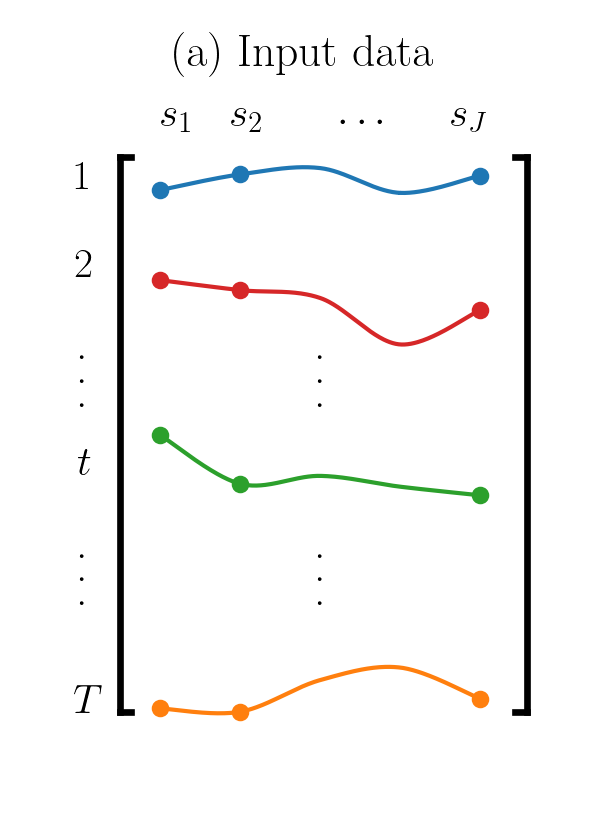

In [7]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 7), dpi=150)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Title
ax.text(0.5, 0.95, "(a) Input data", ha="center", va="center", fontsize=22)

def vertical_dots(x, y_center, gap=0.04, size=22):
    ax.text(x, y_center + gap, ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center,       ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center - gap, ".", fontsize=size, ha="center", va="center")


# Column labels: s1 s2 ... sJ
ax.text(0.28, 0.86, r"$s_1$", fontsize=20, ha="center")
ax.text(0.40, 0.86, r"$s_2$", fontsize=20, ha="center")
ax.text(0.60, 0.86, r"$\cdots$", fontsize=20, ha="center")
ax.text(0.78, 0.86, r"$s_J$", fontsize=20, ha="center")

# Row labels: 1, 2, t, T
ax.text(0.12, 0.78, r"$1$", fontsize=20, ha="center")
ax.text(0.12, 0.67, r"$2$", fontsize=20, ha="center")
ax.text(0.12, 0.42, r"$t$", fontsize=20, ha="center")
ax.text(0.12, 0.12, r"$T$", fontsize=20, ha="center")

# Add vertical dots between 2 and t, and between t and T (near the row labels)
vertical_dots(0.12, 0.55, gap=0.03)
vertical_dots(0.12, 0.30, gap=0.03)
#ax.text(0.12, 0.54, r"$\vdots$", fontsize=22, ha="center", va="center")
#ax.text(0.12, 0.27, r"$\vdots$", fontsize=22, ha="center", va="center")

# Big black brackets
lw_br = 3.2
# left bracket
ax.plot([0.18, 0.18], [0.12, 0.82], lw=lw_br, color="k")
ax.plot([0.18, 0.20], [0.82, 0.82], lw=lw_br, color="k")
ax.plot([0.18, 0.20], [0.12, 0.12], lw=lw_br, color="k")
# right bracket
ax.plot([0.88, 0.88], [0.12, 0.82], lw=lw_br, color="k")
ax.plot([0.86, 0.88], [0.82, 0.82], lw=lw_br, color="k")
ax.plot([0.86, 0.88], [0.12, 0.12], lw=lw_br, color="k")

# Vertical dots inside the matrix (like the sketch)
vertical_dots(0.53, 0.55, gap=0.03)
vertical_dots(0.53, 0.30, gap=0.03)
#ax.text(0.53, 0.55, r"$\vdots$", fontsize=22, ha="center", va="center")
#ax.text(0.53, 0.30, r"$\vdots$", fontsize=22, ha="center", va="center")


# ---------- Smooth curve helper (Catmull–Rom spline) ----------
def catmull_rom_spline(points, n_points=200):
    """
    points: (N,2) array of control points
    returns: (M,2) array of interpolated smooth points
    """
    P = np.asarray(points, float)
    if len(P) < 4:
        # fallback: linear if not enough points
        xs = np.linspace(P[0,0], P[-1,0], n_points)
        ys = np.interp(xs, P[:,0], P[:,1])
        return np.c_[xs, ys]

    # pad endpoints to control end tangents
    Pp = np.vstack([P[0], P, P[-1]])

    curve = []
    # each segment uses 4 points
    for i in range(1, len(Pp) - 2):
        p0, p1, p2, p3 = Pp[i-1], Pp[i], Pp[i+1], Pp[i+2]
        t = np.linspace(0, 1, n_points // (len(P)-1))
        t2, t3 = t*t, t*t*t

        # Catmull-Rom basis
        a = 2*p1
        b = -p0 + p2
        c = 2*p0 - 5*p1 + 4*p2 - p3
        d = -p0 + 3*p1 - 3*p2 + p3

        pts = 0.5 * (a + b*t[:,None] + c*t2[:,None] + d*t3[:,None])
        curve.append(pts)

    return np.vstack(curve)


def wavy(y0, color, seed=0):
    rng = np.random.default_rng(seed)

    # control x positions roughly at s1, s2, ..., sJ
    x = np.linspace(0.25, 0.80, 5)

    # generate a wavy but bounded sequence
    y = y0 + 0.03 * np.cumsum(rng.normal(0, 0.8, size=x.size))
    y = np.clip(y, y0 - 0.08, y0 + 0.08)

    # smooth curve through the control points
    pts = np.c_[x, y]
    smooth = catmull_rom_spline(pts, n_points=220)

    ax.plot(smooth[:, 0], smooth[:, 1], lw=2, color=color, solid_capstyle="round")

    # markers at s1, s2, sJ (i.e., x[0], x[1], x[-1])
    ax.scatter([x[0], x[1], x[-1]],
               [y[0], y[1], y[-1]],
               s=55, color=color, zorder=5)

# Draw example rows
wavy(0.77, "#1F77B4", seed=1)  # blue
wavy(0.66, "#D62728", seed=2)  # red
wavy(0.42, "#2CA02C", seed=3)  # green
wavy(0.14, "#FF7F0E", seed=4)  # orange

plt.savefig("input_data.pdf", bbox_inches="tight")
plt.savefig("input_data.svg", bbox_inches="tight")
plt.show()


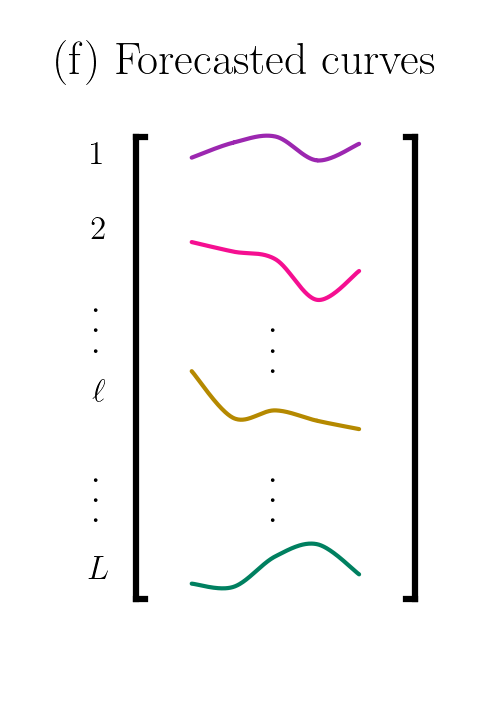

In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 6), dpi=150)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Title
ax.text(0.5, 0.93, "(f) Forecasted curves", ha="center", va="center", fontsize=22)

# Row labels
ax.text(0.18, 0.78, r"$1$", fontsize=16, ha="center")
ax.text(0.18, 0.67, r"$2$", fontsize=16, ha="center")
ax.text(0.18, 0.43, r"$\ell$", fontsize=16, ha="center")
ax.text(0.18, 0.17, r"$L$", fontsize=16, ha="center")

def vertical_dots(x, y_center, gap=0.04, size=22):
    ax.text(x, y_center + gap, ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center,       ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center - gap, ".", fontsize=size, ha="center", va="center")


# Dots on the left (between 2 and ell, and between ell and L)
vertical_dots(0.18, 0.55, gap=0.03)
vertical_dots(0.18, 0.30, gap=0.03)

# Black brackets
lw_br = 3.0
# left bracket
ax.plot([0.26, 0.26], [0.14, 0.82], lw=lw_br, color="k")
ax.plot([0.26, 0.28], [0.82, 0.82], lw=lw_br, color="k")
ax.plot([0.26, 0.28], [0.14, 0.14], lw=lw_br, color="k")
# right bracket
ax.plot([0.86, 0.86], [0.14, 0.82], lw=lw_br, color="k")
ax.plot([0.84, 0.86], [0.82, 0.82], lw=lw_br, color="k")
ax.plot([0.84, 0.86], [0.14, 0.14], lw=lw_br, color="k")

# Dots inside
vertical_dots(0.56, 0.52, gap=0.03)
vertical_dots(0.56, 0.30, gap=0.03)


# Smooth curve helper (Catmull–Rom spline, no SciPy)
def catmull_rom(points, n=180):
    P = np.asarray(points, float)
    Pp = np.vstack([P[0], P, P[-1]])
    out = []
    seg_n = max(20, n // (len(P) - 1))
    for i in range(1, len(Pp) - 2):
        p0, p1, p2, p3 = Pp[i-1], Pp[i], Pp[i+1], Pp[i+2]
        t = np.linspace(0, 1, seg_n)
        t2, t3 = t*t, t*t*t
        a = 2*p1
        b = -p0 + p2
        c = 2*p0 - 5*p1 + 4*p2 - p3
        d = -p0 + 3*p1 - 3*p2 + p3
        out.append(0.5 * (a + b*t[:, None] + c*t2[:, None] + d*t3[:, None]))
    return np.vstack(out)

def draw_curve(y0, color, seed):
    rng = np.random.default_rng(seed)
    x = np.linspace(0.38, 0.74, 5)
    y = y0 + 0.03 * np.cumsum(rng.normal(0, 0.9, size=x.size))
    y = np.clip(y, y0 - 0.08, y0 + 0.08)
    smooth = catmull_rom(np.c_[x, y], n=220)
    ax.plot(smooth[:, 0], smooth[:, 1], lw=2, color=color, solid_capstyle="round")

# Curves (colors similar to your sketch)
draw_curve(0.78, "#9C27B0", seed=1)  # orange
draw_curve(0.66, "#F50F91", seed=2)  # purple
draw_curve(0.42, "#B58900", seed=3)  # teal
draw_curve(0.18, "#008060", seed=4)  # light blue

plt.savefig("forecasted_curves.pdf", bbox_inches="tight")
plt.savefig("forecasted_curves.svg", bbox_inches="tight")
plt.show()


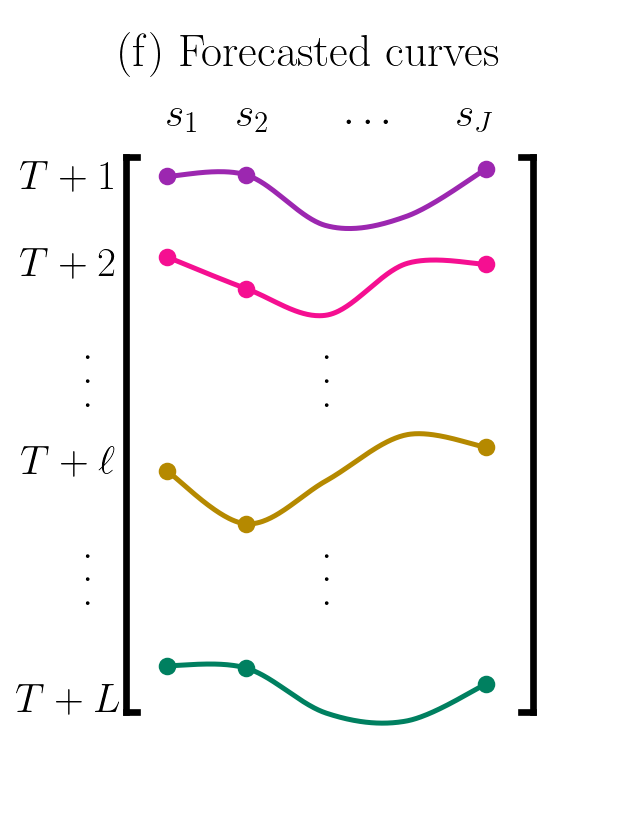

In [10]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 7), dpi=150)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Title
ax.text(0.5, 0.95, "(f) Forecasted curves", ha="center", va="center", fontsize=22)

def vertical_dots(x, y_center, gap=0.04, size=22):
    ax.text(x, y_center + gap, ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center,       ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center - gap, ".", fontsize=size, ha="center", va="center")

# ---- Column labels: s1 s2 ... sJ (same as your input-data figure) ----
ax.text(0.28, 0.86, r"$s_1$", fontsize=20, ha="center")
ax.text(0.40, 0.86, r"$s_2$", fontsize=20, ha="center")
ax.text(0.60, 0.86, r"$\cdots$", fontsize=20, ha="center")
ax.text(0.78, 0.86, r"$s_J$", fontsize=20, ha="center")

# ---- Row labels: 1,2, ell, L ----
ax.text(0.08, 0.78, r"$T+1$", fontsize=20, ha="center")
ax.text(0.08, 0.67, r"$T+2$", fontsize=20, ha="center")
ax.text(0.08, 0.42, r"$T+\ell$", fontsize=20, ha="center")
ax.text(0.08, 0.12, r"$T+L$", fontsize=20, ha="center")

# Dots near row labels (between 2 and ell, between ell and L)
vertical_dots(0.12, 0.55, gap=0.03)
vertical_dots(0.12, 0.30, gap=0.03)

# Big black brackets (same geometry as your input-data figure)
lw_br = 3.2
# left bracket
ax.plot([0.18, 0.18], [0.12, 0.82], lw=lw_br, color="k")
ax.plot([0.18, 0.20], [0.82, 0.82], lw=lw_br, color="k")
ax.plot([0.18, 0.20], [0.12, 0.12], lw=lw_br, color="k")
# right bracket
ax.plot([0.88, 0.88], [0.12, 0.82], lw=lw_br, color="k")
ax.plot([0.86, 0.88], [0.82, 0.82], lw=lw_br, color="k")
ax.plot([0.86, 0.88], [0.12, 0.12], lw=lw_br, color="k")

# Vertical dots inside the matrix
vertical_dots(0.53, 0.55, gap=0.03)
vertical_dots(0.53, 0.30, gap=0.03)

# ---------- Smooth curve helper (Catmull–Rom spline) ----------
def catmull_rom_spline(points, n_points=220):
    P = np.asarray(points, float)
    if len(P) < 4:
        xs = np.linspace(P[0, 0], P[-1, 0], n_points)
        ys = np.interp(xs, P[:, 0], P[:, 1])
        return np.c_[xs, ys]

    Pp = np.vstack([P[0], P, P[-1]])
    curve = []
    seg_n = max(30, n_points // (len(P) - 1))

    for i in range(1, len(Pp) - 2):
        p0, p1, p2, p3 = Pp[i-1], Pp[i], Pp[i+1], Pp[i+2]
        t = np.linspace(0, 1, seg_n)
        t2, t3 = t*t, t*t*t

        a = 2*p1
        b = -p0 + p2
        c = 2*p0 - 5*p1 + 4*p2 - p3
        d = -p0 + 3*p1 - 3*p2 + p3

        pts = 0.5 * (a + b*t[:, None] + c*t2[:, None] + d*t3[:, None])
        curve.append(pts)

    return np.vstack(curve)

# ---------- NEW curve generator (different from your wavy()) ----------
def forecast_curve(y0, color, seed=0):
    rng = np.random.default_rng(seed)

    # same x locations / same length as your input-data code
    x = np.linspace(0.25, 0.80, 5)

    # "totally different" shape: sinusoid + mild trend + tiny noise
    phase = rng.uniform(0, 2*np.pi)
    amp   = rng.uniform(0.03, 0.06)
    trend = rng.uniform(-0.03, 0.03)  # linear drift across s
    noise = rng.normal(0, 0.008, size=x.size)

    s = np.linspace(0, 1, x.size)
    y = y0 + amp * np.sin(2*np.pi*s + phase) + trend*(s - 0.5) + noise
    y = np.clip(y, y0 - 0.09, y0 + 0.09)

    pts = np.c_[x, y]
    smooth = catmull_rom_spline(pts, n_points=240)

    ax.plot(smooth[:, 0], smooth[:, 1], lw=2.4, color=color, solid_capstyle="round")

    # markers at s1, s2, sJ (same as your input-data figure)
    ax.scatter([x[0], x[1], x[-1]],
               [y[0], y[1], y[-1]],
               s=55, color=color, zorder=5)

# Curves (your sharp palette from earlier)
forecast_curve(0.77, "#9C27B0", seed=11)   # purple
forecast_curve(0.66, "#F50F91", seed=22)   # magenta
forecast_curve(0.42, "#B58900", seed=33)   # golden yellow
forecast_curve(0.14, "#008060", seed=44)   # deep teal-green

plt.savefig("forecasted_curves_matrix.pdf", bbox_inches="tight")
plt.savefig("forecasted_curves_matrix.svg", bbox_inches="tight")
plt.show()


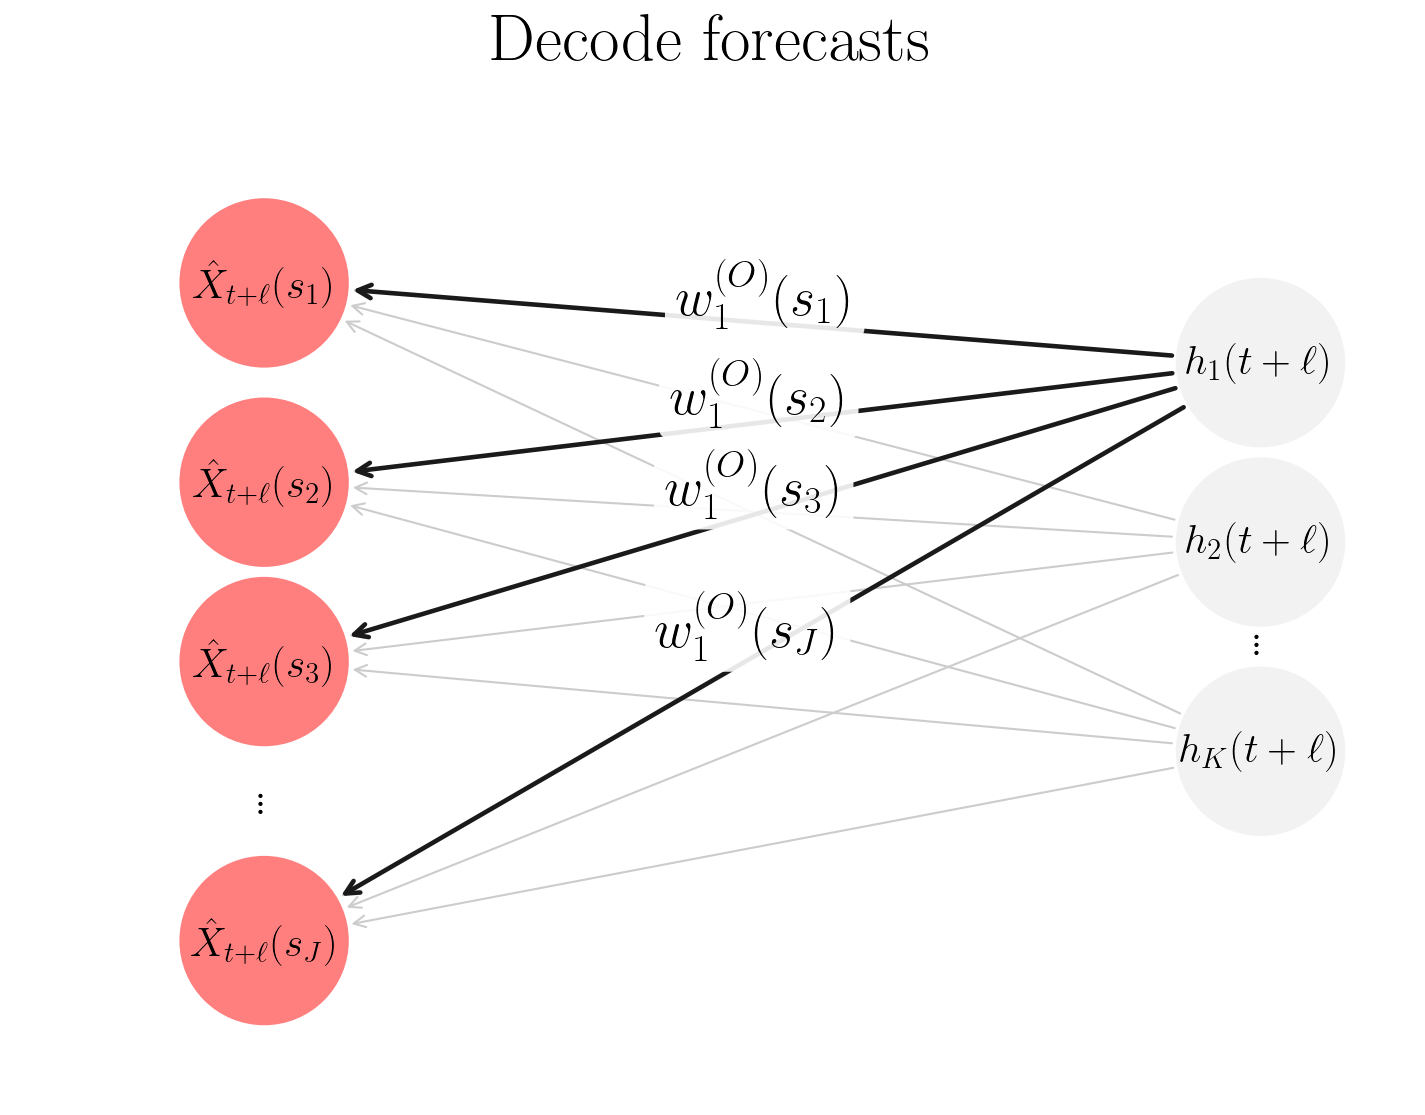

In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# ---------- LaTeX rendering ----------
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 22,
    "text.latex.preamble": r"\usepackage{amsmath}"
})

# ---------- Geometry helpers ----------
def unit(v):
    v = np.array(v, dtype=float)
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

def arrow_endpoints(p1, r1, p2, r2):
    p1 = np.array(p1, float)
    p2 = np.array(p2, float)
    d = p2 - p1
    u = unit(d)
    a = p1 + u * r1
    b = p2 - u * r2
    return a, b

# ---------- Drawing helpers ----------
def add_node(ax, xy, facecolor, text, fontsize=22):
    txt = ax.text(xy[0], xy[1], text, ha="center", va="center",
                  fontsize=fontsize, zorder=10)
    return {"xy": xy, "facecolor": facecolor, "text": text, "txtobj": txt, "r": None}

def compute_radii(ax, groups, pad_px=10):
    renderer = ax.figure.canvas.get_renderer()
    x0 = ax.transData.transform((0, 0))[0]
    x1 = ax.transData.transform((1, 0))[0]
    data_per_px = 1.0 / abs(x1 - x0)

    for group in groups:
        max_r_px = 0
        for nd in group:
            bbox = nd["txtobj"].get_window_extent(renderer=renderer)
            w_px = bbox.width + 2 * pad_px
            h_px = bbox.height + 2 * pad_px
            r_px = 0.5 * np.sqrt(w_px**2 + h_px**2)
            max_r_px = max(max_r_px, r_px)
        for nd in group:
            nd["r"] = max_r_px * data_per_px

def draw_circles(ax, nodes, edge_lw=0.0):
    for nd in nodes:
        circ = Circle(nd["xy"], nd["r"], facecolor=nd["facecolor"],
                      edgecolor=nd["facecolor"], lw=edge_lw, zorder=5)
        ax.add_patch(circ)

def add_arrow(ax, p1, r1, p2, r2, color="0.75", lw=1.2, ms=14, z=2):
    a, b = arrow_endpoints(p1, r1, p2, r2)
    arr = FancyArrowPatch(a, b, arrowstyle="->",
                          mutation_scale=ms, lw=lw, color=color, zorder=z)
    ax.add_patch(arr)

def add_edge_label(ax, p1, r1, p2, r2, label, t=0.5, offset=0.03, fontsize=26, z=20):
    a, b = arrow_endpoints(p1, r1, p2, r2)
    x = (1 - t) * a[0] + t * b[0]
    y = (1 - t) * a[1] + t * b[1]

    d = np.array(b) - np.array(a)
    n = unit([-d[1], d[0]])

    # force "above" direction consistently
    if n[1] < 0:
        n = -n

    x += offset * n[0]
    y += offset * n[1]

    ax.text(x, y, label, ha="center", va="center", fontsize=fontsize, zorder=z,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.9))

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

ax.text(0.5, 1.03, r"Decode forecasts",
        ha="center", va="bottom", fontsize=32, zorder=50,
        transform=ax.transAxes)

ax.axis("off")
ax.set_facecolor("white")
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")

# ---------- Layout (BLUE left, RED right) ----------
xR, xB = 0.05, 1.05
y1, y2, yK = 0.74, 0.56, 0.35
yr1, yr2, yr3, yrJ = 0.82, 0.62, 0.44, 0.16

blue, red = "#f2f2f2ff", "#FF7F7F"

B_pos = [(xB, y1), (xB, y2), (xB, yK)]
R_pos = [(xR, yr1), (xR, yr2), (xR, yr3), (xR, yrJ)]

nodes = []

# Blue nodes: h_k(t+ell)
B = []
for p, t in zip(B_pos, [r"$h_1(t+\ell)$", r"$h_2(t+\ell)$", r"$h_K(t+\ell)$"]):
    nd = add_node(ax, p, blue, t, fontsize=20)
    nodes.append(nd); B.append(nd)

# Red nodes: X-hat_{t+ell}(s_j)
R = []
for p, t in zip(R_pos, [r"$\hat X_{t+\ell}(s_1)$", r"$\hat X_{t+\ell}(s_2)$",
                        r"$\hat X_{t+\ell}(s_3)$", r"$\hat X_{t+\ell}(s_J)$"]):
    nd = add_node(ax, p, red, t, fontsize=20)
    nodes.append(nd); R.append(nd)

# dots
ax.text(xB, 0.46, r"$\vdots$", fontsize=25, ha="center", va="center", zorder=30)
ax.text(xR, 0.30, r"$\vdots$", fontsize=25, ha="center", va="center", zorder=30)

fixed_r = 0.085  # adjust if you want bigger/smaller circles

for nd in nodes:
    nd["r"] = fixed_r

draw_circles(ax, nodes, edge_lw=0.0)

# ---------- Edges ----------
# gray dense connections
for h in B:
    for y in R:
        add_arrow(ax, h["xy"], h["r"], y["xy"], y["r"], color="0.80", lw=1.0, ms=14, z=1)

# black highlighted edges from TOP blue node (h1) to all outputs
h_top = B[0]
for j, y in enumerate(R):
    add_arrow(ax, h_top["xy"], h_top["r"], y["xy"], y["r"], color="0.10", lw=2.2, ms=16, z=5)

# labels centered on each black arrow
add_edge_label(ax, h_top["xy"], h_top["r"], R[0]["xy"], R[0]["r"], r"$w^{(O)}_1(s_1)$", t=0.5, offset=0.03)
add_edge_label(ax, h_top["xy"], h_top["r"], R[1]["xy"], R[1]["r"], r"$w^{(O)}_1(s_2)$", t=0.5, offset=0.03)
add_edge_label(ax, h_top["xy"], h_top["r"], R[2]["xy"], R[2]["r"], r"$w^{(O)}_1(s_3)$", t=0.5, offset=0.03)
add_edge_label(ax, h_top["xy"], h_top["r"], R[3]["xy"], R[3]["r"], r"$w^{(O)}_1(s_J)$", t=0.5, offset=0.03)

plt.savefig("hidden_to_output_forecast.pdf", bbox_inches="tight")
plt.savefig("hidden_to_output_forecast.svg", bbox_inches="tight")
plt.show()


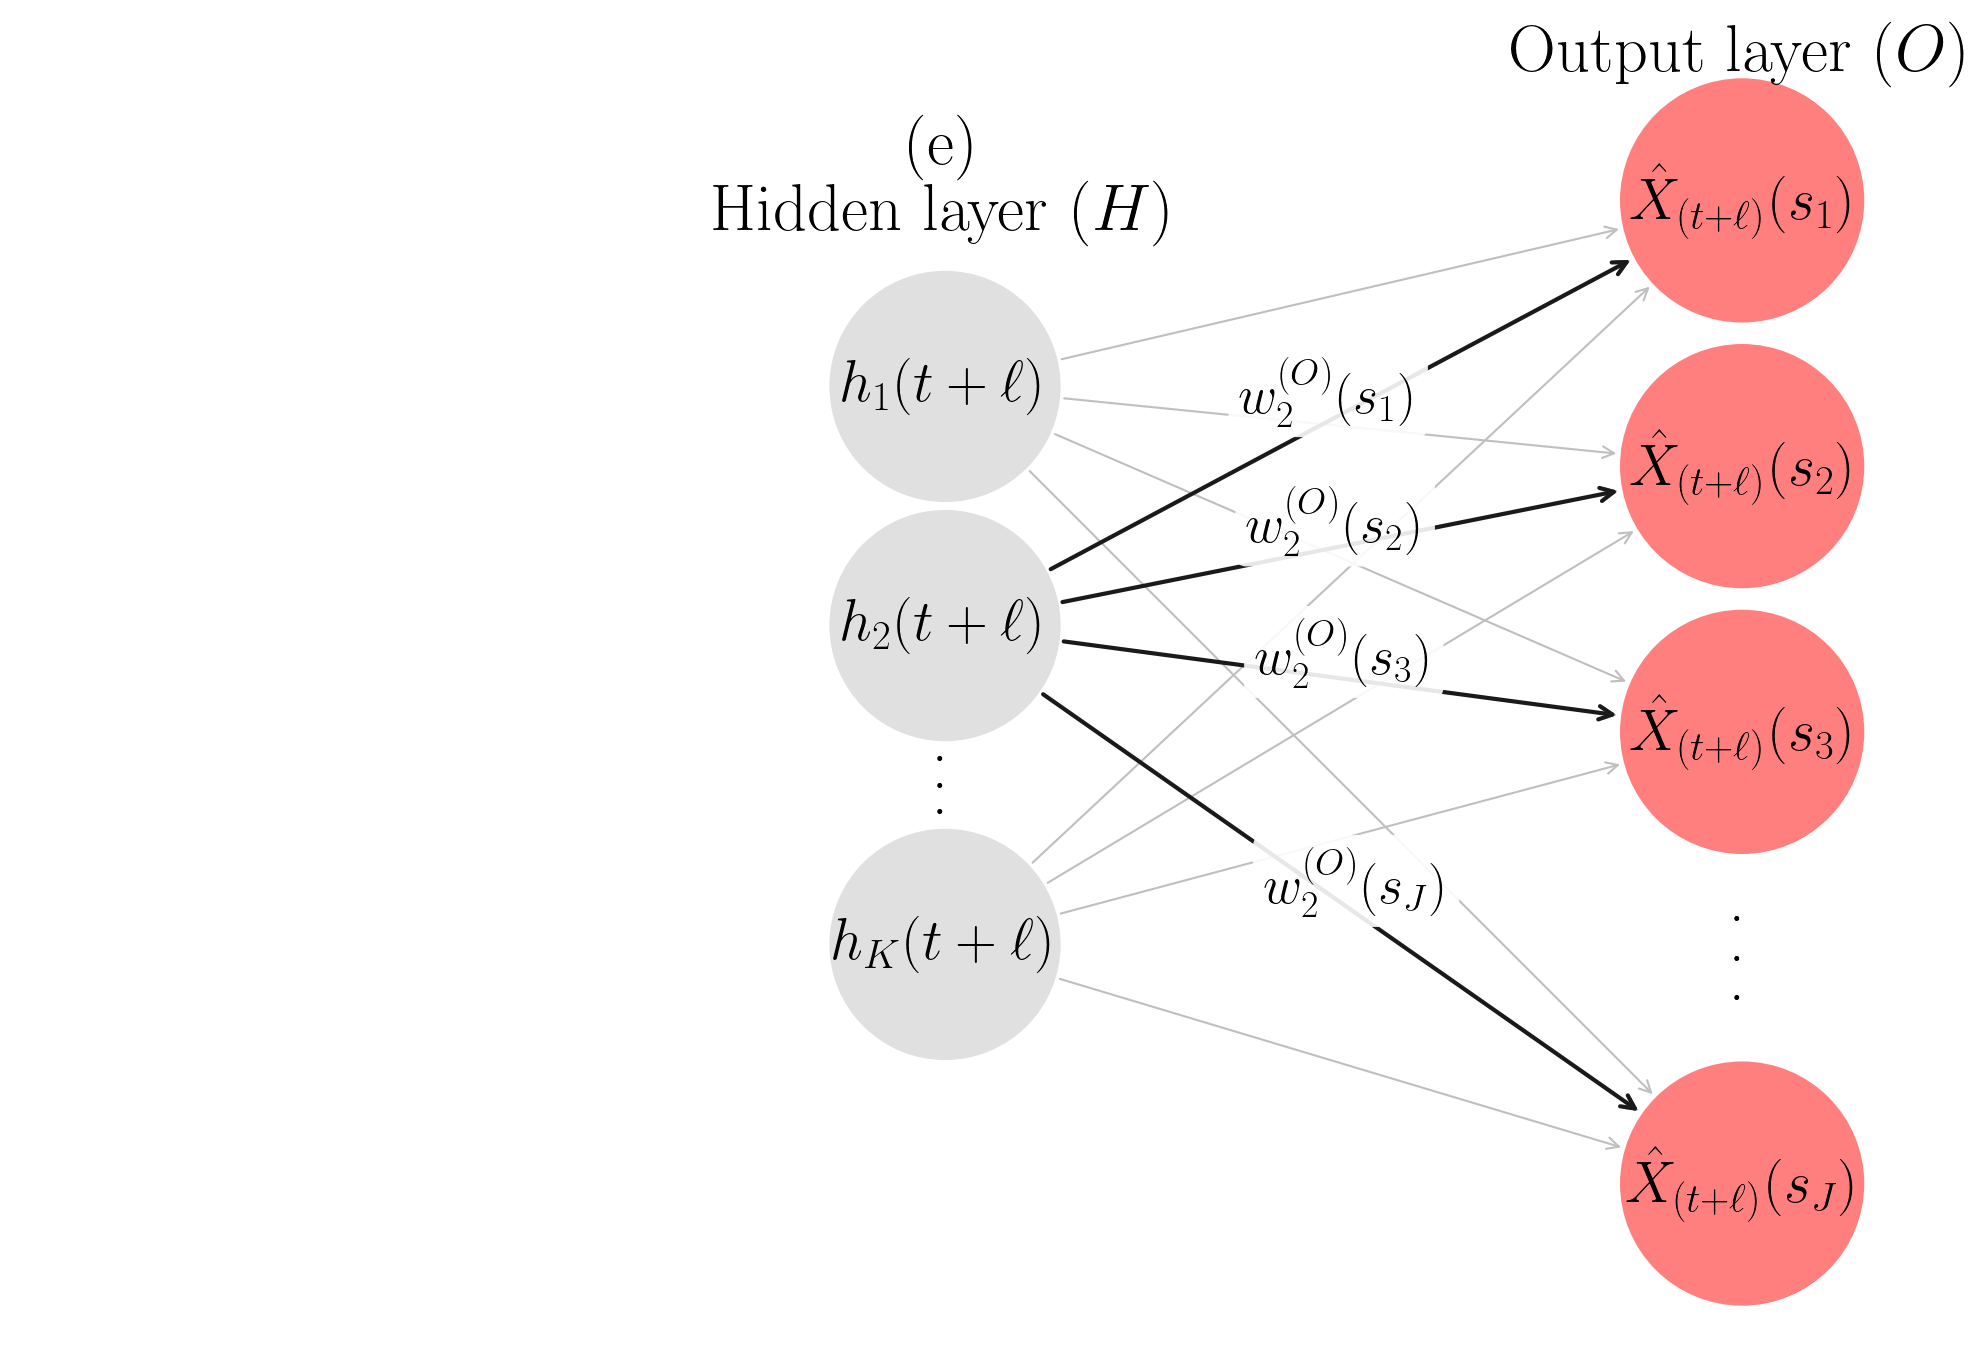

In [127]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# ---------- LaTeX rendering ----------
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 22,  # bigger text overall
    "text.latex.preamble": r"\usepackage{amsmath}"
})

# ---------- Geometry helpers ----------
def unit(v):
    v = np.array(v, dtype=float)
    n = np.linalg.norm(v)
    return v / n if n > 0 else v


def vertical_dots(x, y_center, gap=0.04, size=30):
    ax.text(x, y_center + gap, ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center,       ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center - gap, ".", fontsize=size, ha="center", va="center")


def arrow_endpoints(p1, r1, p2, r2):
    """Return endpoints on the boundaries of circles centered at p1/p2 with radii r1/r2."""
    p1 = np.array(p1, float)
    p2 = np.array(p2, float)
    d = p2 - p1
    u = unit(d)
    a = p1 + u * r1
    b = p2 - u * r2
    return a, b

# ---------- Drawing helpers ----------
def add_node(ax, xy, facecolor, text, fontsize=22):
    """
    Create text first (for measuring), then later we will draw the circle with correct radius.
    Returns a dict holding position, text object, computed radius.
    """
    txt = ax.text(xy[0], xy[1], text, ha="center", va="center",
                  fontsize=fontsize, zorder=10)
    return {"xy": xy, "facecolor": facecolor, "text": text, "txtobj": txt, "r": None}

def compute_radii(ax, groups, pad_px=10):
    """
    groups = list of lists of nodes (e.g., [XL, XM, XR])
    All nodes inside one group get the same radius.
    """
    renderer = ax.figure.canvas.get_renderer()

    # data-units per pixel
    x0 = ax.transData.transform((0, 0))[0]
    x1 = ax.transData.transform((1, 0))[0]
    data_per_px = 1.0 / abs(x1 - x0)

    for group in groups:
        max_r_px = 0

        # find largest text box in this column
        for nd in group:
            bbox = nd["txtobj"].get_window_extent(renderer=renderer)
            w_px = bbox.width + 2 * pad_px
            h_px = bbox.height + 2 * pad_px
            r_px = 0.5 * np.sqrt(w_px**2 + h_px**2)
            max_r_px = max(max_r_px, r_px)

        # assign same radius to all nodes in column
        for nd in group:
            nd["r"] = max_r_px * data_per_px

def draw_circles(ax, nodes, edge_lw=0.0):
    """Draw circles after radii have been computed."""
    for nd in nodes:
        circ = Circle(nd["xy"], nd["r"], facecolor=nd["facecolor"],
                      edgecolor=nd["facecolor"], lw=edge_lw, zorder=5)
        ax.add_patch(circ)

def add_arrow(ax, p1, r1, p2, r2, color="0.75", lw=1.2, ms=14, z=2):
    """Arrow that starts/ends at circle boundaries."""
    a, b = arrow_endpoints(p1, r1, p2, r2)
    arr = FancyArrowPatch(
        a, b, arrowstyle="->",
        mutation_scale=ms,
        lw=lw, color=color,
        zorder=z
    )
    ax.add_patch(arr)

def add_edge_label(ax, p1, r1, p2, r2, label, t=0.5, offset=0.0, fontsize=26, z=20):
    # endpoints of the visible arrow (touching circle boundaries)
    a, b = arrow_endpoints(p1, r1, p2, r2)

    # point on the arrow
    x = (1 - t) * a[0] + t * b[0]
    y = (1 - t) * a[1] + t * b[1]

    # optional small perpendicular offset (keeps it off the line if you want)
    d = np.array(b) - np.array(a)
    n = unit([-d[1], d[0]])
    x += offset * n[0]
    y += offset * n[1]

    ax.text(x, y, label, ha="center", va="center", fontsize=fontsize, zorder=z,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.9))


# ---------- Figure (BIGGER) ----------
fig, ax = plt.subplots(figsize=(16,12), dpi=150)
ax.axis("off")
ax.set_facecolor("white")
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")

# ---------- Layout ----------
xM, xR = 0.50, 1.10
#xL, xM, xR = -0.10, 0.50, 1.10
y1, y2, y3, yJ = 0.86, 0.66, 0.46, 0.12

green, blue, red = "#76F37B", "#E0E0E0", "#FF7F7F"

#XL_pos = [(xL, y1), (xL, y2), (xL, y3), (xL, yJ)]
XM_pos = [(xM, 0.72), (xM, 0.54), (xM, 0.30)]
XR_pos = [(xR, y1), (xR, y2), (xR, y3), (xR, yJ)]

# ---------- Create nodes (text first) ----------
nodes = []


# Hidden (changed LaTeX only)
XM = []
for p, t in zip(XM_pos, [r"$h_1(t+\ell)$", r"$h_2(t+\ell)$", r"$h_K(t+\ell)$"]):
    nd = add_node(ax, p, blue, t, fontsize=28)
    nodes.append(nd)
    XM.append(nd)

# Outputs (changed LaTeX only)
XR = []
for p, t in zip(XR_pos, [r"$\hat X_{(t+\ell)}(s_1)$", r"$\hat X_{(t+\ell)}(s_2)$", r"$\hat X_{(t+\ell)}(s_3)$", r"$\hat X_{(t+\ell)}(s_J)$"]):
    nd = add_node(ax, p, red, t, fontsize=28)
    nodes.append(nd)
    XR.append(nd)

# Dots (not circles)

vertical_dots(xM, 0.43, gap=0.02)
vertical_dots(xR, 0.30, gap=0.03)
#ax.text(xL, 0.28, r"$\vdots$", fontsize=30, ha="center", va="center", zorder=30)
#ax.text(xM, 0.45, r"$\vdots$", fontsize=30, ha="center", va="center", zorder=30)
#ax.text(xR, 0.28, r"$\vdots$", fontsize=30, ha="center", va="center", zorder=30)

# ---------- Measure text -> compute radii -> draw circles ----------
fig.canvas.draw()                 # IMPORTANT: needed before measuring bbox
compute_radii(ax, [XM, XR], pad_px=0)
draw_circles(ax, nodes, edge_lw=0.0)

# ---------- Edges ----------
# Gray dense connections

for h in XM:
    for y in XR:
        add_arrow(ax, h["xy"], h["r"], y["xy"], y["r"], color="0.75", lw=1.0, ms=14, z=1)

# Highlighted edges (black) -> second hidden node h_2(t)

for y in XR:
    add_arrow(ax, XM[1]["xy"], XM[1]["r"], y["xy"], y["r"], color="0.10", lw=2.0, ms=16, z=5)

# ---------- Weight labels (changed LaTeX only) ----------

# Hidden → output (black labels centered on arrow)
add_edge_label(ax, XM[1]["xy"], XM[1]["r"], XR[0]["xy"], XR[0]["r"], r"$w^{(O)}_2(s_1)$", t=0.5, offset=0.02)
add_edge_label(ax, XM[1]["xy"], XM[1]["r"], XR[1]["xy"], XR[1]["r"], r"$w^{(O)}_2(s_2)$", t=0.5, offset=0.02)
add_edge_label(ax, XM[1]["xy"], XM[1]["r"], XR[2]["xy"], XR[2]["r"], r"$w^{(O)}_2(s_3)$", t=0.5, offset=0.02)
add_edge_label(ax, XM[1]["xy"], XM[1]["r"], XR[3]["xy"], XR[3]["r"], r"$w^{(O)}_2(s_J)$", t=0.5, offset=0.02)


# ---------- Column titles (NEW) ----------
y_title = 0.97
#ax.text(xL, y_title, r"Input layer $(I)$",  ha="center", va="center", fontsize=32, zorder=50)
ax.text(xM, 0.9, r"(e)", ha="center", va="center", fontsize=32, zorder=50)
ax.text(xM, 0.85, r"Hidden layer $(H)$", ha="center", va="center", fontsize=32, zorder=50)
ax.text(xR, y_title, r"Output layer $(O)$", ha="center", va="center", fontsize=32, zorder=50)


# ---------- Export (big, clean) ----------
plt.savefig("hidden_to_output_forecast.pdf", bbox_inches="tight")  # vector PDF
plt.savefig("hidden_to_output_forecast.svg", bbox_inches="tight")  # vector SVG
#plt.savefig("fae_latex_big2.png", bbox_inches="tight", dpi=200)  # high-res PNG
plt.show()

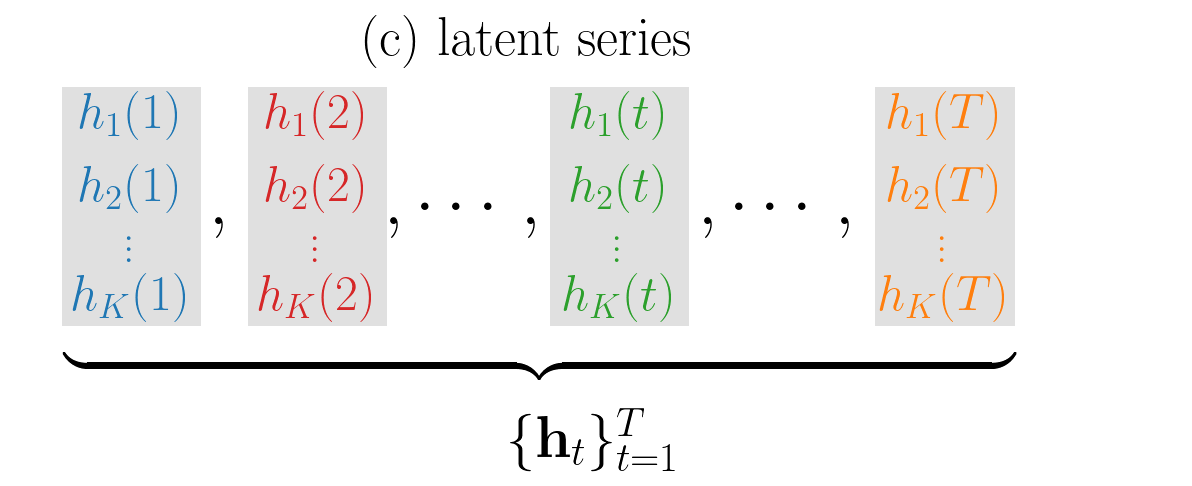

In [70]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --- LaTeX style like your other figures ---
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 24,
    "text.latex.preamble": r"\usepackage{amsmath}"
})

# --- Figure canvas ---
fig, ax = plt.subplots(figsize=(10, 3.2), dpi=150)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# ---------------------------
# 1) Column x positions
#    Make blue->red closer by bringing the 2nd column left
# ---------------------------
xs = [0.10, 0.26, 0.52, 0.80]   # <- changed 0.32 -> 0.26 to reduce that gap

# Colors per shown columns
cols = ["#1F77B4", "#D62728", "#2CA02C", "#FF7F0E"]

# Column labels for time index (t = 1, 2, ell, T)
t_labels = [r"1", r"2", r"t", r"T"]

# y positions for h1, h2, ..., hk
y_top, y_mid, y_vdots, y_bot = 0.78, 0.58, 0.44, 0.28

# ---------------------------
# 2) Light gray boxes behind each column
# ---------------------------
box_color = "#E0E0E0"
box_w = 0.12          # width of each column box (tune if you want tighter)
box_y0 = 0.20         # bottom of box
box_h  = 0.66         # height of box

for x in xs:
    ax.add_patch(
        Rectangle(
            (x - box_w/2, box_y0),
            box_w, box_h,
            facecolor=box_color,
            edgecolor="none",
            zorder=0
        )
    )

# ---------------------------
# Draw each shown column (text on top of boxes)
# ---------------------------
def vertical_dots(x, y_center, gap=0.04, size=22, col="#E0E0E0"):
    ax.text(x, y_center + gap, ".", fontsize=size,
            ha="center", va="center", color=col)
    ax.text(x, y_center, ".", fontsize=size,
            ha="center", va="center", color=col)
    ax.text(x, y_center - gap, ".", fontsize=size,
            ha="center", va="center", color=col)

for x, c, tlab in zip(xs, cols, t_labels):
    ax.text(x, y_top, rf"$h_1({tlab})$", color=c, ha="center", va="center", zorder=2)
    ax.text(x, y_mid, rf"$h_2({tlab})$", color=c, ha="center", va="center", zorder=2)
    vertical_dots(x, y_vdots, gap=0.03, col=c)
    ax.text(x, y_bot, rf"$h_K({tlab})$", color=c, ha="center", va="center", zorder=2)


# ---------------------------
# Commas / ellipses BETWEEN columns:
# place them automatically at midpoints so spacing is consistent
# ---------------------------
mid12 = (xs[0] + xs[1]) / 2
mid23 = (xs[1] + xs[2]) / 2
mid34 = (xs[2] + xs[3]) / 2

ax.text(mid12, 0.53, r"$,$",       ha="center", va="center", fontsize=34, zorder=2)
ax.text(mid23, 0.53, r"$,\cdots,$",ha="center", va="center", fontsize=34, zorder=2)
ax.text(mid34, 0.53, r"$,\cdots,$",ha="center", va="center", fontsize=34, zorder=2)

# ---------------------------
# Bottom brace + label
# ---------------------------
ax.text(0.45, 0.16,
        r"$\underbrace{\qquad\qquad\qquad\qquad\qquad}$",
        ha="center", va="center", fontsize=50)

ax.text(0.50, -0.20, r"$\{\mathbf{h}_t\}_{t=1}^{T}$",
        ha="center", va="bottom", fontsize=28)

ax.text(0.30, 1.06, r"(c) latent series",
        ha="left", va="top", fontsize=26)

plt.savefig("ht_sequence_brace.pdf", bbox_inches="tight")
plt.savefig("ht_sequence_brace.svg", bbox_inches="tight")
plt.show()


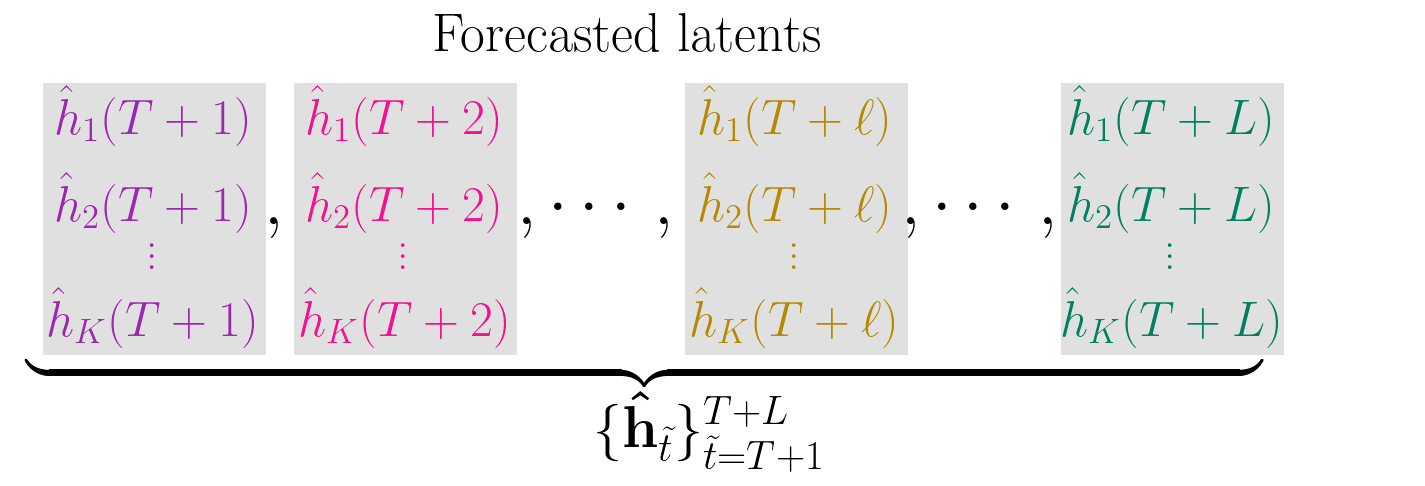

In [8]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --- LaTeX style like your other figures ---
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 24,
    "text.latex.preamble": r"\usepackage{amsmath}"
})

# --- Figure canvas ---
fig, ax = plt.subplots(figsize=(12, 3.2), dpi=150)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# ---------------------------
# 1) Column x positions
#    Make blue->red closer by bringing the 2nd column left
# ---------------------------
xs = [0.10, 0.28, 0.56, 0.83]   # <- changed 0.32 -> 0.26 to reduce that gap

# Colors per shown columns
cols = ["#9C27B0", "#F50F91", "#B58900", "#008060"]



# Column labels for time index (t = 1, 2, ell, T)
t_labels = [r"T+1", r"T+2", r"T+\ell", r"T+L"]

# y positions for h1, h2, ..., hk
y_top, y_mid, y_vdots, y_bot = 0.78, 0.54, 0.42, 0.22

# ---------------------------
# 2) Light gray boxes behind each column
# ---------------------------
box_color = "#E0E0E0"
box_w = 0.16          # width of each column box (tune if you want tighter)
box_y0 = 0.12         # bottom of box
box_h  = 0.75         # height of box

for x in xs:
    ax.add_patch(
        Rectangle(
            (x - box_w/2, box_y0),
            box_w, box_h,
            facecolor=box_color,
            edgecolor="none",
            zorder=0
        )
    )

# ---------------------------
# Draw each shown column (text on top of boxes)
# ---------------------------
def vertical_dots(x, y_center, gap=0.04, size=22, col="#E0E0E0"):
    ax.text(x, y_center + gap, ".", fontsize=size,
            ha="center", va="center", color=col)
    ax.text(x, y_center, ".", fontsize=size,
            ha="center", va="center", color=col)
    ax.text(x, y_center - gap, ".", fontsize=size,
            ha="center", va="center", color=col)

for x, c, tlab in zip(xs, cols, t_labels):
    ax.text(x, y_top, rf"$\hat{{h}}_1({tlab})$", color=c, ha="center", va="center", zorder=2)
    ax.text(x, y_mid, rf"$\hat{{h}}_2({tlab})$", color=c, ha="center", va="center", zorder=2)
    vertical_dots(x, y_vdots, gap=0.03, col=c)
    ax.text(x, y_bot, rf"$\hat{{h}}_K({tlab})$", color=c, ha="center", va="center", zorder=2)

# ---------------------------
# Commas / ellipses BETWEEN columns:
# place them automatically at midpoints so spacing is consistent
# ---------------------------
mid12 = (xs[0] + xs[1]) / 2
mid23 = (xs[1] + xs[2]) / 2
mid34 = (xs[2] + xs[3]) / 2

ax.text(mid12, 0.53, r"$,$",       ha="center", va="center", fontsize=34, zorder=2)
ax.text(mid23, 0.53, r"$,\cdots,$",ha="center", va="center", fontsize=34, zorder=2)
ax.text(mid34, 0.53, r"$,\cdots,$",ha="center", va="center", fontsize=34, zorder=2)

# ---------------------------
# Bottom brace + label
# ---------------------------
ax.text(0.45, 0.16,
        r"$\underbrace{\qquad\qquad\qquad\qquad\qquad}$",
        ha="center", va="center", fontsize=65)

ax.text(0.50, -0.20, r"$\{\mathbf{\hat{h}}_{\tilde{t}}\}_{\tilde{t}=T+1}^{T+L}$",
        ha="center", va="bottom", fontsize=28)

ax.text(0.30, 1.06, r"Forecasted latents",
        ha="left", va="top", fontsize=26)

plt.savefig("forecasted_ht.pdf", bbox_inches="tight")
plt.savefig("forecasted_ht.svg", bbox_inches="tight")
plt.show()


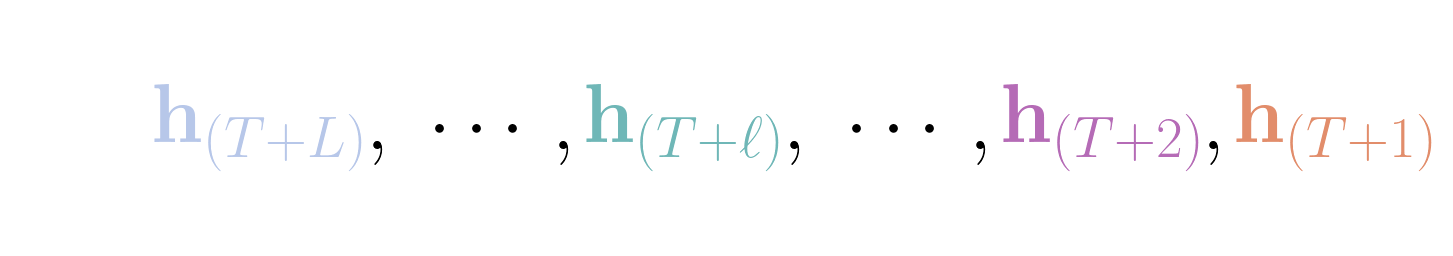

In [71]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# LaTeX style
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 26,
    "text.latex.preamble": r"\usepackage{amsmath}"
})

def latex_sentence(ax, x, y, parts, fontsize=34, pad_px=6):
    """
    parts = list of tuples: (latex_string, color)
    x,y are in Axes coords (0..1). Places parts inline using rendered widths.
    """
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    # axes width in pixels
    ax_w_px = ax.get_window_extent(renderer=renderer).width

    x_curr = x
    for s, col in parts:
        t = ax.text(x_curr, y, s,
                    transform=ax.transAxes,
                    ha="left", va="center",
                    fontsize=fontsize,
                    color=col if col is not None else "k")
        fig.canvas.draw()
        bb = t.get_window_extent(renderer=renderer)
        x_curr += (bb.width + pad_px) / ax_w_px


fig, ax = plt.subplots(figsize=(8, 2), dpi=150)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Colors
c1 = "#9BB9E8"   # light blue
c2 = "#6FA8DC"   # blue
c3 = "#B57EDC"   # purple
c4 = "#E27C5C"   # orange

parts = [
    (r"$\mathbf{h}_{(T+L)}$",   "#B7C7E9"),
    (r"$,\ \cdots,\ $", None),
    (r"$\mathbf{h}_{(T+\ell)}$", "#6FB7B7"),
    (r"$,\ \cdots,\ $", None),
    (r"$\mathbf{h}_{(T+2)}$",   "#B56BB6"),
    (r"$,\ $", None),
    (r"$\mathbf{h}_{(T+1)}$",   "#E28D6B"),
]


latex_sentence(ax, x=0.15, y=0.5, parts=parts, fontsize=40, pad_px=4)


plt.savefig("forecasted_ht.pdf", bbox_inches="tight")
plt.savefig("forecasted_ht.svg", bbox_inches="tight")
plt.show()


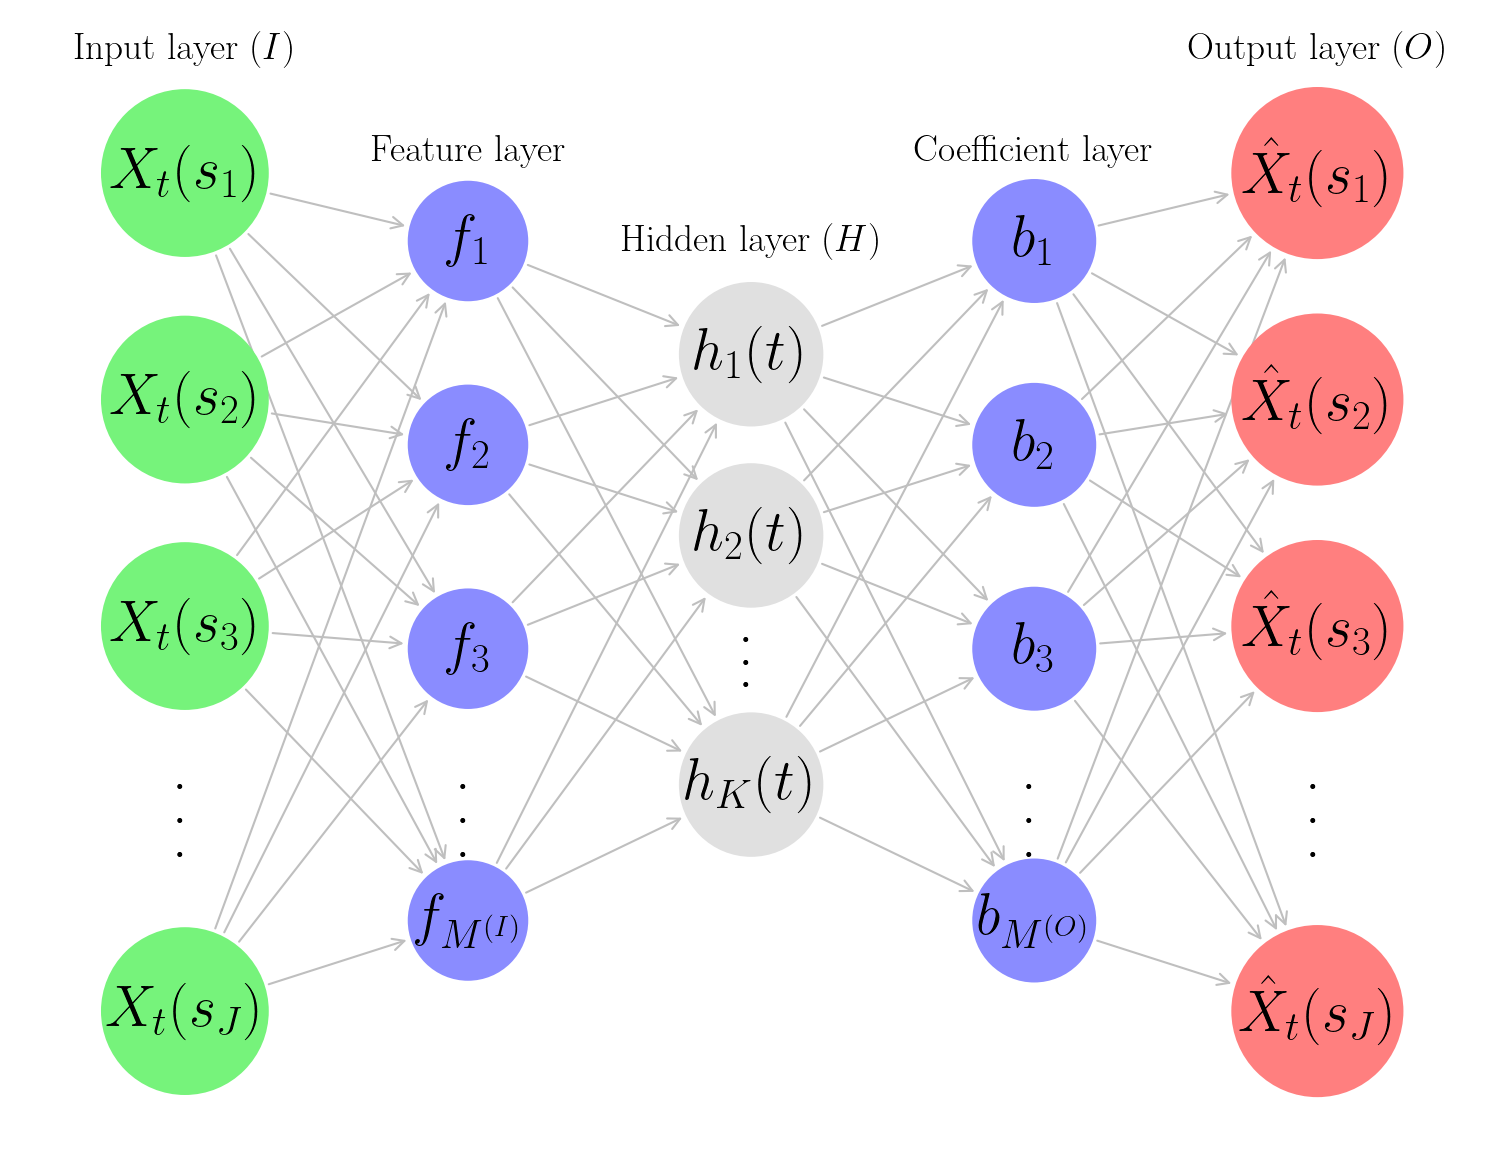

In [14]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# ---------- LaTeX rendering ----------
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 22,
    "text.latex.preamble": r"\usepackage{amsmath}"
})

# ---------- Geometry helpers ----------
def unit(v):
    v = np.array(v, dtype=float)
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

def vertical_dots(ax, x, y_center, gap=0.04, size=30):
    ax.text(x, y_center + gap, ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center,       ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center - gap, ".", fontsize=size, ha="center", va="center")

def arrow_endpoints(p1, r1, p2, r2):
    p1 = np.array(p1, float)
    p2 = np.array(p2, float)
    d = p2 - p1
    u = unit(d)
    a = p1 + u * r1
    b = p2 - u * r2
    return a, b

# ---------- Drawing helpers ----------
def add_node(ax, xy, facecolor, text, fontsize=28):
    txt = ax.text(xy[0], xy[1], text, ha="center", va="center",
                  fontsize=fontsize, zorder=10)
    return {"xy": xy, "facecolor": facecolor, "text": text, "txtobj": txt, "r": None}

def compute_radii(ax, groups, pad_px=16):
    renderer = ax.figure.canvas.get_renderer()

    # data-units per pixel (x-direction)
    x0 = ax.transData.transform((0, 0))[0]
    x1 = ax.transData.transform((1, 0))[0]
    data_per_px = 1.0 / abs(x1 - x0)

    for group in groups:
        max_r_px = 0
        for nd in group:
            bbox = nd["txtobj"].get_window_extent(renderer=renderer)
            w_px = bbox.width + 2 * pad_px
            h_px = bbox.height + 2 * pad_px
            r_px = 0.5 * np.sqrt(w_px**2 + h_px**2)
            max_r_px = max(max_r_px, r_px)
        for nd in group:
            nd["r"] = max_r_px * data_per_px

def draw_circles(ax, nodes, edge_lw=0.0):
    for nd in nodes:
        circ = Circle(nd["xy"], nd["r"], facecolor=nd["facecolor"],
                      edgecolor=nd["facecolor"], lw=edge_lw, zorder=5)
        ax.add_patch(circ)

def add_arrow(ax, p1, r1, p2, r2, color="0.75", lw=1.0, ms=14, z=2):
    a, b = arrow_endpoints(p1, r1, p2, r2)
    arr = FancyArrowPatch(
        a, b, arrowstyle="->",
        mutation_scale=ms,
        lw=lw, color=color,
        zorder=z
    )
    ax.add_patch(arr)

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(18, 10), dpi=150)
ax.axis("off")
ax.set_facecolor("white")
ax.set_xlim(-0.15, 1.15)
ax.set_ylim(0, 1)
ax.set_aspect("equal")

# ---------- Layout (5 columns now) ----------
xI, xF, xH, xC, xO = 0, 0.25, 0.50, 0.75, 1
y1, y2, y3, yJ = 0.86, 0.66, 0.46, 0.12

green = "#76F37B"
blue  = "#8A8CFF"   # blue for Feature + Coefficient layers
hidden_color = "#E0E0E0"
red   = "#FF7F7F"

# positions: (4 shown + dots in middle)
I_pos = [(xI, y1), (xI, y2), (xI, y3), (xI, yJ)]
F_pos = [(xF, 0.80), (xF, 0.62), (xF, 0.44), (xF, 0.20)]
H_pos = [(xH, 0.70), (xH, 0.54), (xH, 0.32)]
C_pos = [(xC, 0.80), (xC, 0.62), (xC, 0.44), (xC, 0.20)]
O_pos = [(xO, y1), (xO, y2), (xO, y3), (xO, yJ)]

# ---------- Create nodes (text first) ----------
nodes = []

I = []
for p, t in zip(I_pos, [r"$X_t(s_1)$", r"$X_t(s_2)$", r"$X_t(s_3)$", r"$X_t(s_J)$"]):
    nd = add_node(ax, p, green, t)
    nodes.append(nd); I.append(nd)

F = []
for p, t in zip(F_pos, [r"$f_1$", r"$f_2$", r"$f_3$", r"$f_{M^{(I)}}$"]):
    nd = add_node(ax, p, blue, t)
    nodes.append(nd); F.append(nd)

H = []
for p, t in zip(H_pos, [r"$h_1(t)$", r"$h_2(t)$", r"$h_K(t)$"]):
    nd = add_node(ax, p, hidden_color, t)
    nodes.append(nd); H.append(nd)

C = []
for p, t in zip(C_pos, [r"$b_1$", r"$b_2$", r"$b_3$", r"$b_{M^{(O)}}$"]):
    nd = add_node(ax, p, blue, t)
    nodes.append(nd); C.append(nd)

O = []
for p, t in zip(O_pos, [r"$\hat X_t(s_1)$", r"$\hat X_t(s_2)$", r"$\hat X_t(s_3)$", r"$\hat X_t(s_J)$"]):
    nd = add_node(ax, p, red, t)
    nodes.append(nd); O.append(nd)

# dots (not circles)
vertical_dots(ax, xI, 0.30, gap=0.03)
vertical_dots(ax, xF, 0.30, gap=0.03)
vertical_dots(ax, xH, 0.44, gap=0.02)
vertical_dots(ax, xC, 0.30, gap=0.03)
vertical_dots(ax, xO, 0.30, gap=0.03)

# ---------- Measure text -> compute radii -> draw circles ----------
fig.canvas.draw()
compute_radii(ax, [I, F, H, C, O], pad_px=0)
draw_circles(ax, nodes, edge_lw=0.0)

# ---------- Edges (ALL gray, NO labels) ----------
edge_color = "0.75"
for a in I:
    for b in F:
        add_arrow(ax, a["xy"], a["r"], b["xy"], b["r"], color=edge_color, lw=1.0, ms=14, z=1)

for a in F:
    for b in H:
        add_arrow(ax, a["xy"], a["r"], b["xy"], b["r"], color=edge_color, lw=1.0, ms=14, z=1)

for a in H:
    for b in C:
        add_arrow(ax, a["xy"], a["r"], b["xy"], b["r"], color=edge_color, lw=1.0, ms=14, z=1)

for a in C:
    for b in O:
        add_arrow(ax, a["xy"], a["r"], b["xy"], b["r"], color=edge_color, lw=1.0, ms=14, z=1)

# ---------- Column titles ----------
ax.text(xI, 0.97, r"Input layer $(I)$", ha="center", va="center", fontsize=18, zorder=50)
ax.text(xF, 0.88, r"Feature layer",     ha="center", va="center", fontsize=18, zorder=50)
ax.text(xH, 0.8, r"Hidden layer $(H)$",ha="center", va="center", fontsize=18, zorder=50)
ax.text(xC, 0.88, r"Coefficient layer", ha="center", va="center", fontsize=18, zorder=50)
ax.text(xO, 0.97, r"Output layer $(O)$",ha="center", va="center", fontsize=18, zorder=50)

# ---------- Export ----------
plt.savefig("fae_5layers.pdf", bbox_inches="tight")
plt.savefig("fae_5layers.svg", bbox_inches="tight")
plt.show()


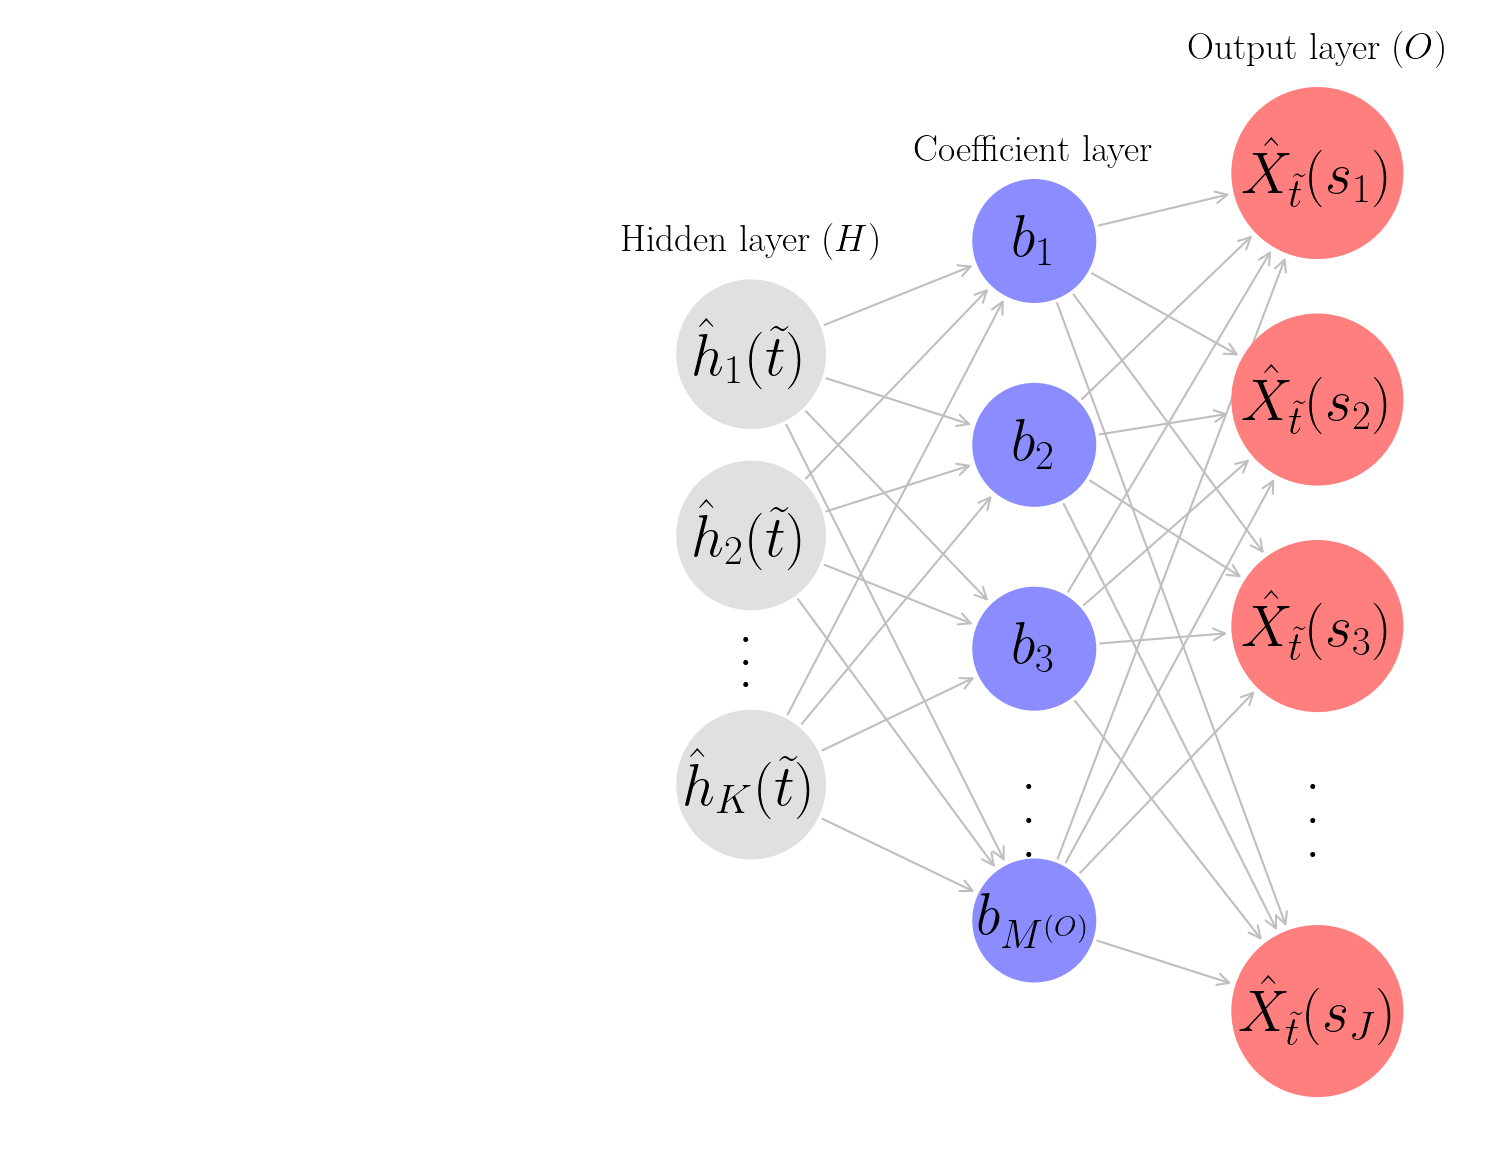

In [16]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# ---------- LaTeX rendering ----------
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 22,
    "text.latex.preamble": r"\usepackage{amsmath}"
})

# ---------- Geometry helpers ----------
def unit(v):
    v = np.array(v, dtype=float)
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

def vertical_dots(ax, x, y_center, gap=0.04, size=30):
    ax.text(x, y_center + gap, ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center,       ".", fontsize=size, ha="center", va="center")
    ax.text(x, y_center - gap, ".", fontsize=size, ha="center", va="center")

def arrow_endpoints(p1, r1, p2, r2):
    p1 = np.array(p1, float)
    p2 = np.array(p2, float)
    d = p2 - p1
    u = unit(d)
    a = p1 + u * r1
    b = p2 - u * r2
    return a, b

# ---------- Drawing helpers ----------
def add_node(ax, xy, facecolor, text, fontsize=28):
    txt = ax.text(xy[0], xy[1], text, ha="center", va="center",
                  fontsize=fontsize, zorder=10)
    return {"xy": xy, "facecolor": facecolor, "text": text, "txtobj": txt, "r": None}

def compute_radii(ax, groups, pad_px=16):
    renderer = ax.figure.canvas.get_renderer()

    x0 = ax.transData.transform((0, 0))[0]
    x1 = ax.transData.transform((1, 0))[0]
    data_per_px = 1.0 / abs(x1 - x0)

    for group in groups:
        max_r_px = 0
        for nd in group:
            bbox = nd["txtobj"].get_window_extent(renderer=renderer)
            w_px = bbox.width + 2 * pad_px
            h_px = bbox.height + 2 * pad_px
            r_px = 0.5 * np.sqrt(w_px**2 + h_px**2)
            max_r_px = max(max_r_px, r_px)
        for nd in group:
            nd["r"] = max_r_px * data_per_px

def draw_circles(ax, nodes, edge_lw=0.0):
    for nd in nodes:
        circ = Circle(nd["xy"], nd["r"], facecolor=nd["facecolor"],
                      edgecolor=nd["facecolor"], lw=edge_lw, zorder=5)
        ax.add_patch(circ)

def add_arrow(ax, p1, r1, p2, r2, color="0.75", lw=1.0, ms=14, z=2):
    a, b = arrow_endpoints(p1, r1, p2, r2)
    arr = FancyArrowPatch(
        a, b, arrowstyle="->",
        mutation_scale=ms,
        lw=lw, color=color,
        zorder=z
    )
    ax.add_patch(arr)

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(18, 10), dpi=150)
ax.axis("off")
ax.set_facecolor("white")
ax.set_xlim(-0.15, 1.15)
ax.set_ylim(0, 1)
ax.set_aspect("equal")

# ---------- Layout (3 columns now) ----------
xH, xC, xO = 0.50, 0.75, 1
y1, y2, y3, yJ = 0.86, 0.66, 0.46, 0.12

hidden_color = "#E0E0E0"
blue  = "#8A8CFF"
red   = "#FF7F7F"

H_pos = [(xH, 0.70), (xH, 0.54), (xH, 0.32)]
C_pos = [(xC, 0.80), (xC, 0.62), (xC, 0.44), (xC, 0.20)]
O_pos = [(xO, y1), (xO, y2), (xO, y3), (xO, yJ)]

# ---------- Create nodes ----------
nodes = []

H = []
for p, t in zip(H_pos, [r"$\hat{{h}}_1(\tilde{t})$", r"$\hat{{h}}_2(\tilde{t})$", r"$\hat{{h}}_K(\tilde{t})$"]):
    nd = add_node(ax, p, hidden_color, t)
    nodes.append(nd); H.append(nd)

C = []
for p, t in zip(C_pos, [r"$b_1$", r"$b_2$", r"$b_3$", r"$b_{M^{(O)}}$"]):
    nd = add_node(ax, p, blue, t)
    nodes.append(nd); C.append(nd)

O = []
for p, t in zip(O_pos, [r"$\hat X_{\tilde{t}}(s_1)$",
                       r"$\hat X_{\tilde{t}}(s_2)$",
                       r"$\hat X_{\tilde{t}}(s_3)$",
                       r"$\hat X_{\tilde{t}}(s_J)$"]):
    nd = add_node(ax, p, red, t)
    nodes.append(nd); O.append(nd)


# dots
vertical_dots(ax, xH, 0.44, gap=0.02)
vertical_dots(ax, xC, 0.30, gap=0.03)
vertical_dots(ax, xO, 0.30, gap=0.03)

# ---------- Radii + circles ----------
fig.canvas.draw()
compute_radii(ax, [H, C, O], pad_px=0)
draw_circles(ax, nodes, edge_lw=0.0)

# ---------- Edges ----------
edge_color = "0.75"

for a in H:
    for b in C:
        add_arrow(ax, a["xy"], a["r"], b["xy"], b["r"],
                  color=edge_color, lw=1.0, ms=14, z=1)

for a in C:
    for b in O:
        add_arrow(ax, a["xy"], a["r"], b["xy"], b["r"],
                  color=edge_color, lw=1.0, ms=14, z=1)

# ---------- Column titles ----------
ax.text(xH, 0.8, r"Hidden layer $(H)$", ha="center", va="center", fontsize=18)
ax.text(xC, 0.88, r"Coefficient layer", ha="center", va="center", fontsize=18)
ax.text(xO, 0.97, r"Output layer $(O)$", ha="center", va="center", fontsize=18)

# ---------- Export ----------
plt.savefig("fae_3layers.pdf", bbox_inches="tight")
plt.savefig("fae_3layers.svg", bbox_inches="tight")
plt.show()
